# Classificazione dell'Abbandono Aziendale (Employee Attrition)
**Business Intelligence per Big Data — Politecnico di Torino, AA 2025-2026**

**Obiettivo:** predire se un dipendente lascerà l'azienda (Attrition = 1) o rimarrà (Attrition = 0), usando algoritmi di classificazione supervisionata. Il modello supporta le strategie di retention HR identificando preventivamente i dipendenti a rischio.

## 1. Import Librerie

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve)

random_seed = 42 

import warnings
#warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)


## 2. Caricamento dei Dati

Il dataset è diviso in train (600 righe) e test (150 righe). Il test set non viene mai usato nella fase di addestramento.

In [24]:
train_with_label = pd.read_excel('C:\\Users\\39389\\Desktop\\BusinessIntelligencePerBigData_attrition\\materiale_attrition\\attrition_train.xlsx')
test  = pd.read_excel('C:\\Users\\39389\\Desktop\\BusinessIntelligencePerBigData_attrition\\materiale_attrition\\attrition_test.xlsx')
train = train_with_label.drop(columns=['Attrition'])

print(f'Train and label: {train_with_label.shape[0]} righe, {train.shape[1]} colonne')
print(f'Test:  {test.shape[0]} righe,  {test.shape[1]} colonne')
print(f'Train: {train.shape[0]} righe, {train.shape[1]} colonne')

Train and label: 600 righe, 32 colonne
Test:  150 righe,  33 colonne
Train: 600 righe, 32 colonne


In [25]:
train.head()

,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Engagement_Score,Tenure_Instability,Random_Survey_Noise
0,31,Male,Married,1,3,Life Sciences,Research & Development,Laboratory Technician,2,Travel_Rarely,...,7,16,0,1,5,0,4,2.99,0.033,52.86
1,38,Male,Single,12,3,Other,Sales,Laboratory Technician,4,Travel_Rarely,...,16,12,5,7,0,1,3,1.72,0.519,32.29
2,40,Female,Married,14,4,Life Sciences,Sales,Research Scientist,2,Travel_Frequently,...,26,1,5,1,1,2,2,2.41,0.479,23.27
3,39,Male,Married,7,4,Medical,Research & Development,Laboratory Technician,2,Travel_Rarely,...,17,11,5,0,9,5,5,2.56,0.012,53.69
4,34,Female,Married,5,2,Life Sciences,Research & Development,Research Scientist,2,Non-Travel,...,19,4,2,0,1,3,1,3.17,-0.017,60.57


## 3. Esplorazione dei Dati

### 3.1 Attribute types and Attribute values nel dataset
Si esplora il tipo e i valori degli attributi presenti nel dataset. In particolare per il tipo si distingue in:

Variabili numeriche (quantitative) 
- Intervalli
- ratio

Variabili categoriche (qualitative):
- Nominali
- Ordinali 

e discreta/continua

In [26]:

print('Tipi di variabili:')
print(train.dtypes.value_counts())
print()
type_obj_var = train.select_dtypes(include='object').columns.tolist()

nomi_colonne = train.columns.tolist()
print(f"Il dataset contiene {len(nomi_colonne)} colonne (attributi + variabile label) :")
print(nomi_colonne)

train.head()

Tipi di variabili:
int64      22
str         7
float64     3
Name: count, dtype: int64

Il dataset contiene 32 colonne (attributi + variabile label) :
['Age', 'Gender', 'MaritalStatus', 'DistanceFromHome', 'Education', 'EducationField', 'Department', 'JobRole', 'JobLevel', 'BusinessTravel', 'OverTime', 'MonthlyIncome', 'DailyRate', 'HourlyRate', 'PercentSalaryHike', 'StockOptionLevel', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction', 'JobInvolvement', 'PerformanceRating', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked', 'TrainingTimesLastYear', 'Engagement_Score', 'Tenure_Instability', 'Random_Survey_Noise']


C:\Users\39389\AppData\Local\Temp\ipykernel_47492\1504852645.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  type_obj_var = train.select_dtypes(include='object').columns.tolist()


,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Engagement_Score,Tenure_Instability,Random_Survey_Noise
0,31,Male,Married,1,3,Life Sciences,Research & Development,Laboratory Technician,2,Travel_Rarely,...,7,16,0,1,5,0,4,2.99,0.033,52.86
1,38,Male,Single,12,3,Other,Sales,Laboratory Technician,4,Travel_Rarely,...,16,12,5,7,0,1,3,1.72,0.519,32.29
2,40,Female,Married,14,4,Life Sciences,Sales,Research Scientist,2,Travel_Frequently,...,26,1,5,1,1,2,2,2.41,0.479,23.27
3,39,Male,Married,7,4,Medical,Research & Development,Laboratory Technician,2,Travel_Rarely,...,17,11,5,0,9,5,5,2.56,0.012,53.69
4,34,Female,Married,5,2,Life Sciences,Research & Development,Research Scientist,2,Non-Travel,...,19,4,2,0,1,3,1,3.17,-0.017,60.57


#### Variabili di tipo int/float

In [27]:
# Analisi Variabili di tipo int/float
type_float_int_var = train.select_dtypes(include=['int64', 'float64'])

df_type_float_int = pd.DataFrame({'Tipo': type_float_int_var.dtypes,'Valori_unici': type_float_int_var.nunique(), 'Min': type_float_int_var.min(), 'Max': type_float_int_var.max(), 'Media': type_float_int_var.mean(),  'Varianza': type_float_int_var.var()})
df_type_float_int = df_type_float_int.round({
    'Min': 2, 'Max': 2, 'Media': 2, 'Varianza': 2
})

print("\n--- Analisi variabili numeriche ---")
print(df_type_float_int)





--- Analisi variabili numeriche ---
                             Tipo  Valori_unici      Min       Max    Media  \
Age                         int64            42    18.00     60.00    37.08   
DistanceFromHome            int64            29     1.00     29.00     8.97   
Education                   int64             5     1.00      5.00     2.91   
JobLevel                    int64             5     1.00      5.00     2.19   
MonthlyIncome               int64           570  1009.00  19999.00  5937.64   
DailyRate                   int64           485   102.00   1498.00   843.66   
HourlyRate                  int64            70    30.00     99.00    64.47   
PercentSalaryHike           int64            14    11.00     24.00    17.45   
StockOptionLevel            int64             4     0.00      3.00     0.92   
JobSatisfaction             int64             4     1.00      4.00     2.72   
EnvironmentSatisfaction     int64             4     1.00      4.00     2.66   
WorkLifeBalance

#### Variabili di tipo object

In [28]:
# Analisi Variabili di tipo Object

type_obj_var = train.select_dtypes(include='object').columns
var_obj_cat_to_encode = type_obj_var.tolist()
print("\n --- Analisi variabili di tipo object")

for col in var_obj_cat_to_encode:
    print(f"\n>>> {col.upper()}")
    print(train[col].value_counts().to_string())
    print("-" * 30)



 --- Analisi variabili di tipo object

>>> GENDER
Gender
Male      342
Female    258
------------------------------

>>> MARITALSTATUS
MaritalStatus
Married     291
Single      184
Divorced    125
------------------------------

>>> EDUCATIONFIELD
EducationField
Life Sciences       240
Medical             179
Marketing            88
Other                47
Technical Degree     46
------------------------------

>>> DEPARTMENT
Department
Research & Development    376
Sales                     183
Human Resources            41
------------------------------

>>> JOBROLE
JobRole
Sales Executive              142
Research Scientist           115
Laboratory Technician         97
Manufacturing Director        65
Healthcare Representative     55
Manager                       46
Sales Representative          31
Research Director             28
Human Resources               21
------------------------------

>>> BUSINESSTRAVEL
BusinessTravel
Travel_Rarely        428
Non-Travel           119
Tra

C:\Users\39389\AppData\Local\Temp\ipykernel_47492\3733684180.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  type_obj_var = train.select_dtypes(include='object').columns


Considerando il tipo di dato in python, numero di valori unici, il min e il max nella tabella e il significato degli attributi:
Si distinguono quindi 
- variabili nominali: Gender, MaritalStatus, EducationField, Department, JobRole, BusinessTravel, OverTime.
- variabili ordinali: Education, JobLevel, JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance, RelationshipSatisfaction, JobInvolvement, PerformanceRating.
- variabili quantitative: Age, DistanceFromHome, MonthlyIncome, DailyRate, HourlyRate, PercentSalaryHike, StockOptionLevel,TotalWorkingYears,YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, NumCompaniesWorked, TrainingTimesLastYear, Engagement_Score.

Tra le quantitative le variabili continue (rappresentate in floating numbers) sono: Engagement_Score, Tenure_Instability, Random_Survey_Noise

Le variabili con un vasto set di attribute values (>= 40) sono le variabili: Age, MonthlyIncome, DailyRate, HourlyRate, Tenure_Instability, 
Random_Survey_Noise 
-> Utile per considerare una possibile Data discretization: tecnica di preprocessing usata per trasformare dati in intervalli discreti o categorie. 

### 3.2 Distribuzione della Classe Target

Il dataset è **sbilanciato**: la maggior parte dei dipendenti non ha lasciato l'azienda. Questo impatta:
1) La scelta delle metriche di valutazione: l'accuracy da sola non è sufficiente, occorre guardare **Recall** e **F1-score** sulla classe minoritaria (Attrition = 1).
2) La scelta di effettuare una cross validation che tenga conto di questo sbilanciamento: verrà usata la StratifiedKFold

Distribuzione classi nel train set:
Attrition
0    507
1     93
Name: count, dtype: int64

Percentuale abbandono (classe 1): 15.5%


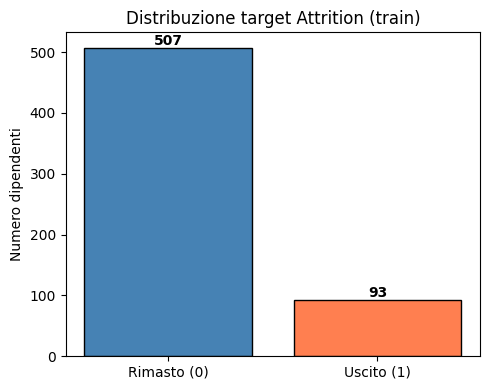

In [29]:
counts = train_with_label['Attrition'].value_counts().sort_index()
print('Distribuzione classi nel train set:')
print(counts)
print(f'\nPercentuale abbandono (classe 1): {counts[1] / len(train) * 100:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Rimasto (0)', 'Uscito (1)'], counts.values,
       color=['steelblue', 'coral'], edgecolor='black')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax.set_title('Distribuzione target Attrition (train)')
ax.set_ylabel('Numero dipendenti')
plt.tight_layout()
plt.show()

In [30]:
def check_global_inconsistencies(df):
    # 1. Controlli rispetto a YearsAtCompany (già fatti, li raggruppiamo)
    inc_manager_co = df[df['YearsAtCompany'] < df['YearsWithCurrManager']]
    inc_promo_co   = df[df['YearsAtCompany'] < df['YearsSinceLastPromotion']]
    inc_role_co    = df[df['YearsAtCompany'] < df['YearsInCurrentRole']]
    
    # 2. NUOVI CONTROLLI: Rispetto a TotalWorkingYears
    # Gli anni totali di carriera devono essere >= anni in questa azienda
    inc_co_total      = df[df['TotalWorkingYears'] < df['YearsAtCompany']]
    # Gli anni totali di carriera devono essere >= anni nel ruolo attuale
    inc_role_total    = df[df['TotalWorkingYears'] < df['YearsInCurrentRole']]
    # Gli anni totali di carriera devono essere >= anni col manager attuale
    inc_manager_total = df[df['TotalWorkingYears'] < df['YearsWithCurrManager']]

    print(f"--- ANALISI INCOERENZE LOGICHE (DETTAGLIATA) ---")
    print(f"Righe totali: {len(df)}\n")
    print(f"ERRORE: Anni in Azienda < Anni con Manager: {len(inc_manager_co)}")
    print(f"ERRORE: Anni in Azienda < Anni Promozione:  {len(inc_promo_co)}")
    print(f"ERRORE: Anni in Azienda < Anni Ruolo:      {len(inc_role_co)}")
    print("-" * 40)
    print(f"ERRORE: Carriera Totale < Anni in Azienda: {len(inc_co_total)}")
    print(f"ERRORE: Carriera Totale < Anni Ruolo:      {len(inc_role_total)}")
    print(f"ERRORE: Carriera Totale < Anni con Manager: {len(inc_manager_total)}")
    
    # Creiamo un set unico di indici di righe "corrotte"
    corrupted_indices = set(inc_manager_co.index) | set(inc_promo_co.index) | \
                        set(inc_role_co.index) | set(inc_co_total.index) | \
                        set(inc_role_total.index) | set(inc_manager_total.index)
    
    print(f"\nTOTALE RIGHE UNICHE CON ALMENO UN ERRORE: {len(corrupted_indices)} ({len(corrupted_indices)/len(df)*100:.1f}%)")
    
    return list(corrupted_indices)

# Esecuzione (ricorda di usare il nome della tua variabile, es. train_df o df)
dirty_rows_indices = check_global_inconsistencies(train_with_label)

--- ANALISI INCOERENZE LOGICHE (DETTAGLIATA) ---
Righe totali: 600

ERRORE: Anni in Azienda < Anni con Manager: 181
ERRORE: Anni in Azienda < Anni Promozione:  109
ERRORE: Anni in Azienda < Anni Ruolo:      189
----------------------------------------
ERRORE: Carriera Totale < Anni in Azienda: 199
ERRORE: Carriera Totale < Anni Ruolo:      114
ERRORE: Carriera Totale < Anni con Manager: 112

TOTALE RIGHE UNICHE CON ALMENO UN ERRORE: 437 (72.8%)




## 3.2 Data Discretization

La discretizzazione è un processo di data reduction che riduce la cardinalità del dominio di un attributo . Si applica in modo non supervisionato tramite equal-width o equal-frequency binning.

Le feature discretizzate vengono preservate nel dataset parallelamente alle versioni continue originali. Le versioni continue saranno preferite per Decision Tree e Random Forest(????), che applicano internamente una discretizzazione supervisionata ottimale rispetto al target. Le versioni discretizzate potranno risultare più adatte in presenza di relazioni non lineari tra feature e Attrition e sono comunque utili per l'analisi esplorativa e la comprensione del dataset.

Operativamente, prima visualizziamo gli attributi potenzialmente discretizzabili, come si distribuiscono (ignoro i vari years... aspettando risposta da prof). 

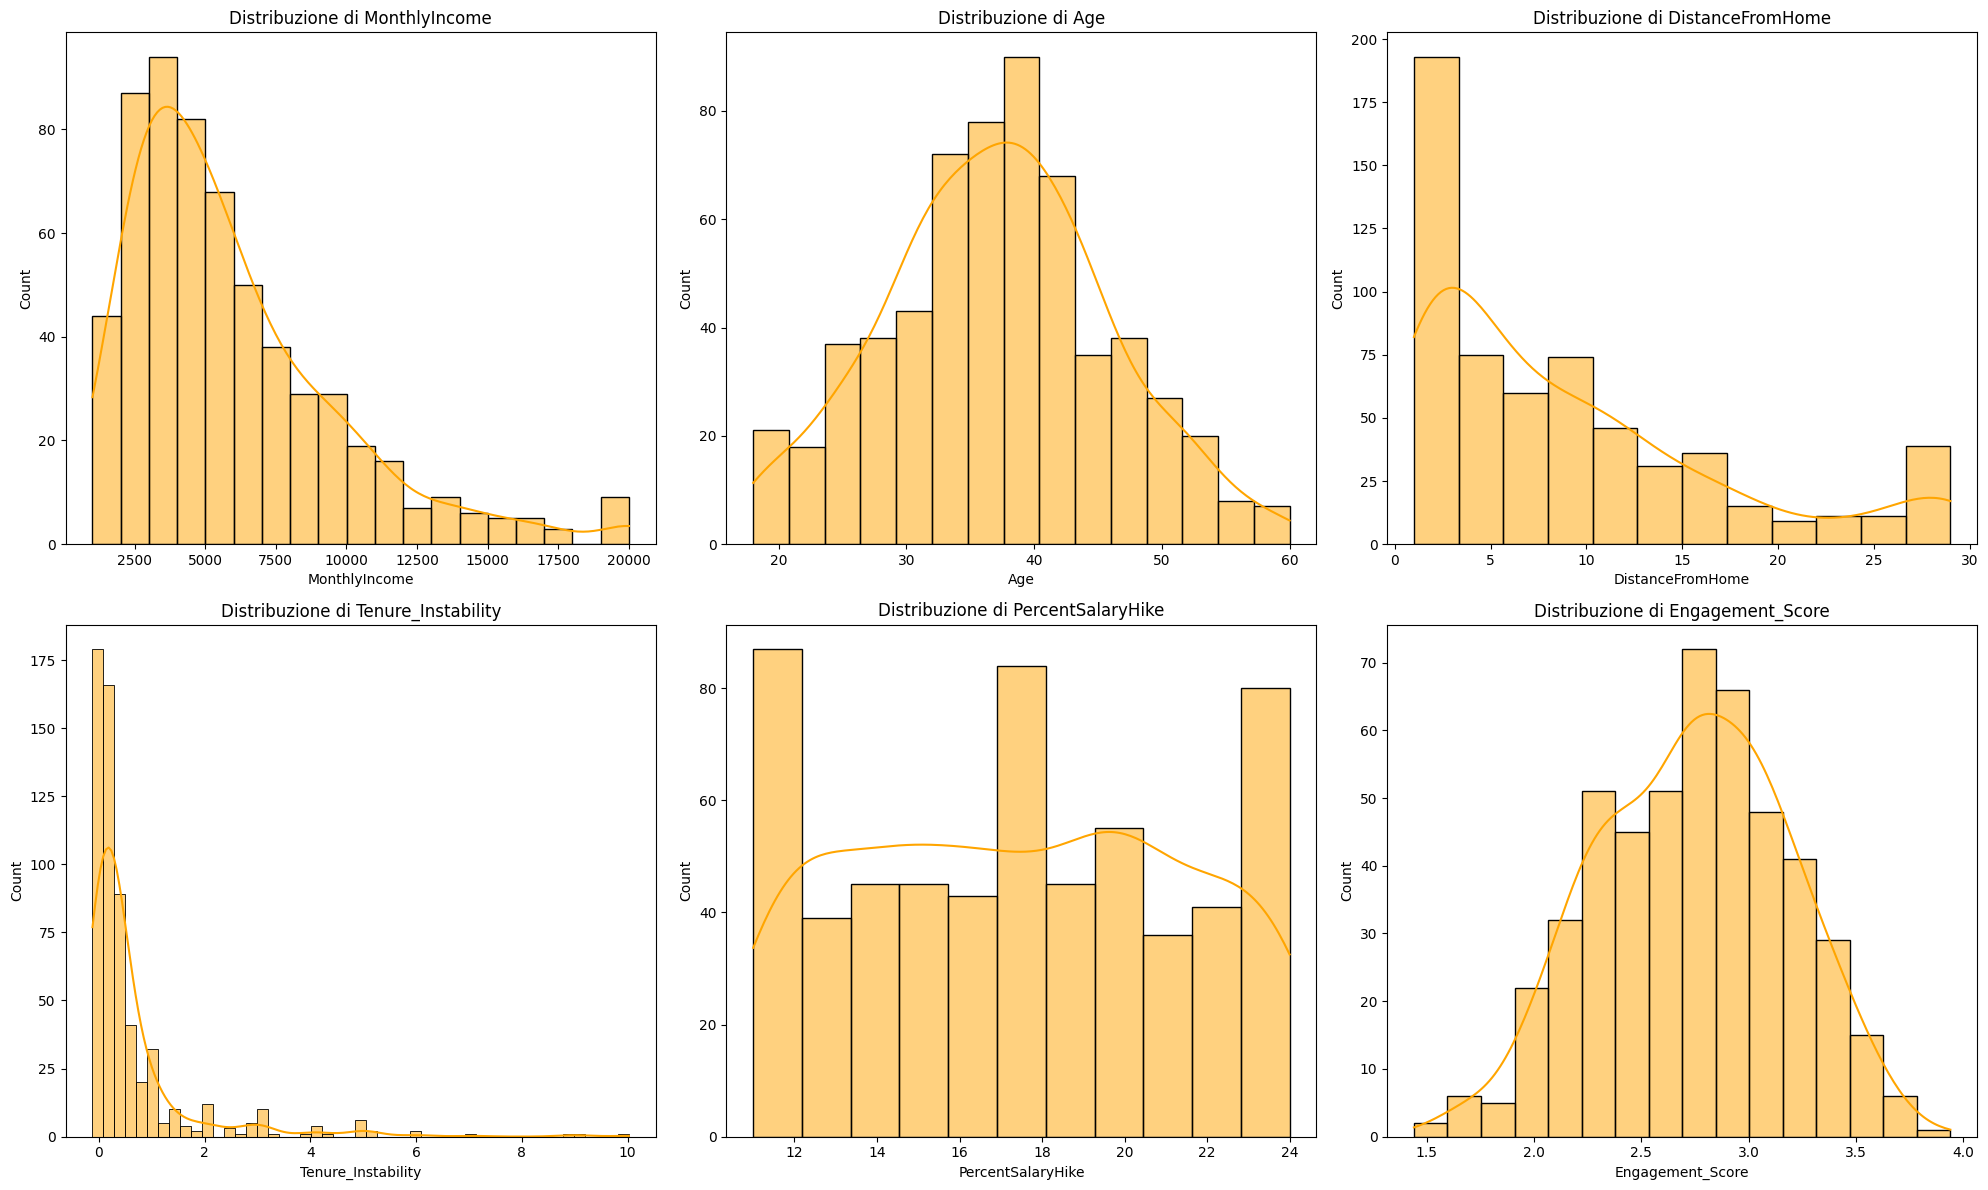

MonthlyIncome: 570 valori unici
Age: 42 valori unici
DistanceFromHome: 29 valori unici
Tenure_Instability: 447 valori unici
PercentSalaryHike: 14 valori unici
Engagement_Score: 168 valori unici


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista dei candidati su cui riflettere (esclusi gli "Years" per ora)
candidati_riflessione = [
    'MonthlyIncome', 'Age', 'DistanceFromHome', 
    'Tenure_Instability', 'PercentSalaryHike', 'Engagement_Score'
]

plt.figure(figsize=(20, 12))
for i, col in enumerate(candidati_riflessione, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train_with_label[col], kde=True, color='orange')
    plt.title(f'Distribuzione di {col}')

plt.tight_layout()
plt.show()

# Stampiamo anche i valori unici per capire la "granularità"
for col in candidati_riflessione:
    print(f"{col}: {train_with_label[col].nunique()} valori unici")

Da questa vsiualizzazione risulta:

1. MonthlyIncome - Da discretizzare per frequenza per far si che ogni fascia abbia lo stesso numero di oggetti. Presenta una distribuzione fortemente asimmetrica (considera che verranno rimossi gli outliers -> coda destra).
2. Age - Presenta una distribuzione a campana, da discretizzare magari tenendo conto del fatto che uno junior magari tende di più ad abbandonare rispetto a un senior. DA APPROFONDIRE TIPO DI DISCRETIZZAZIONE
3. DistanceFromHome - Qui la distanza ha un "punto di rottura". Oltre i 15-20 km il pendolarismo diventa un peso. Potrebbe aver senso fare 3 fasce: "Vicino", "Moderato", "Lontano".
4. Tenure_Instability - Fortemente asimmetrico, considera potenziali outliers. Possibile discretizzazione (3 o 4 bin): fasce rischio stagnazione (basso, medio, alto ad esempio).
5. PercentSalaryHike - Pochi valori -> NO DISCRETIZZAZIONE.
6. Engagement_Score - Distribuzione a campana, si potrebbe considerare di isolare chi è fortemente insoddisfatto (magari discretizzazione by binning).

**Discretizzazione di MonthlyIncome**

In [32]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le = LabelEncoder()
y = train_with_label['Attrition']

# Creiamo le tre diverse spaccature nel dataset
train_with_label['Income_4_Bins'] = pd.qcut(train_with_label['MonthlyIncome'], q=4)
train_with_label['Income_5_Bins'] = pd.qcut(train_with_label['MonthlyIncome'], q=5)
train_with_label['Income_10_Bins'] = pd.qcut(train_with_label['MonthlyIncome'], q=10)

# Prepariamo la tabella di test codificando i testi in numeri
X_income_test = pd.DataFrame()
X_income_test['Originale'] = train_with_label['MonthlyIncome']
X_income_test['4_Bin'] = le.fit_transform(train_with_label['Income_4_Bins'])
X_income_test['5_Bin'] = le.fit_transform(train_with_label['Income_5_Bins'])
X_income_test['10_Bin'] = le.fit_transform(train_with_label['Income_10_Bins'])

# Calcoliamo la Mutual Information (tutte le colonne tranne l'originale sono discrete)
mi_income = mutual_info_classif(X_income_test, y, discrete_features=[1, 2, 3], random_state=42)

print("--- CONFRONTO DISCRETIZZAZIONE MONTHLY INCOME ---")
print(f"Mutual Info - Reddito Originale: {mi_income[0]:.4f}")
print(f"Mutual Info - Con 4 Bin:          {mi_income[1]:.4f}")
print(f"Mutual Info - Con 5 Bin: {mi_income[2]:.4f}")
print(f"Mutual Info - Con 10 Bin:         {mi_income[3]:.4f}")


# Creiamo le nuove spaccature spingendoci più avanti
train_with_label['Income_15_Bins'] = pd.qcut(train_with_label['MonthlyIncome'], q=15)
train_with_label['Income_20_Bins'] = pd.qcut(train_with_label['MonthlyIncome'], q=20)
train_with_label['Income_30_Bins'] = pd.qcut(train_with_label['MonthlyIncome'], q=30)

# Prepariamo la tabella di test
X_deep_test = pd.DataFrame()
X_deep_test['10_Bin'] = le.fit_transform(train_with_label['Income_10_Bins'])
X_deep_test['15_Bin'] = le.fit_transform(train_with_label['Income_15_Bins'])
X_deep_test['20_Bin'] = le.fit_transform(train_with_label['Income_20_Bins'])
X_deep_test['30_Bin'] = le.fit_transform(train_with_label['Income_30_Bins'])

# Calcoliamo la MI per questo nuovo blocco
mi_deep = mutual_info_classif(X_deep_test, y, discrete_features=[0, 1, 2, 3], random_state=42)

print("--- ESPLORAZIONE AD ALTA GRANULARITÀ MONTHLY INCOME ---")
print(f"Mutual Info - Con 10 Bin: {mi_deep[0]:.4f}")
print(f"Mutual Info - Con 15 Bin: {mi_deep[1]:.4f}")
print(f"Mutual Info - Con 20 Bin: {mi_deep[2]:.4f}, ATTENZIONE ALTRO RISCHIO OVERFITTING")




--- CONFRONTO DISCRETIZZAZIONE MONTHLY INCOME ---
Mutual Info - Reddito Originale: 0.0000
Mutual Info - Con 4 Bin:          0.0005
Mutual Info - Con 5 Bin: 0.0002
Mutual Info - Con 10 Bin:         0.0042
--- ESPLORAZIONE AD ALTA GRANULARITÀ MONTHLY INCOME ---
Mutual Info - Con 10 Bin: 0.0042
Mutual Info - Con 15 Bin: 0.0037
Mutual Info - Con 20 Bin: 0.0142, ATTENZIONE ALTRO RISCHIO OVERFITTING


**Scelta della Discretizzazione per 'MonthlyIncome'**

La discretizzazione per frequenza uguale a **10 bin (Decili)** garantisce un supporto statistico robusto (~60 osservazioni per bin) e riduce la sensibilità del modello agli outlier salariali. Il confronto della Mutual Information mostra che 10 bin (MI ≈ 0.0042) rappresentano il punto di equilibrio ottimale: valori inferiori (4-5 bin) perdono segnale, 
valori superiori (20+ bin) introducono rischio di overfitting.

Si preservano entrambe le versioni dell'attributo nel dataset:
- `MonthlyIncome`: valore continuo originale, preferibile per modelli ad albero e 
  regressione logistica con scaling, poiché questi trovano autonomamente i punti di taglio.
- `Monthly_Income_Bin`: versione discretizzata a decili, utile per l'analisi esplorativa 
  del tasso di attrition per fascia salariale e potenzialmente per algoritmi che beneficiano di input categorici.

La scelta definitiva di quale versione includere nei modelli verrà effettuata in fase di 
sperimentazione, valutando l'impatto sulle metriche di classificazione.


In [33]:
train_with_label['Monthly_Income_Bin'] = pd.qcut(train_with_label['MonthlyIncome'], q=10, labels=[f'Decile_{i}' for i in range(1, 11)])

**Discretizzazione di Age**


In [34]:

le = LabelEncoder()
y = train_with_label['Attrition']

# 1. Applichiamo l'Ampiezza Uguale (Equal Width) usando pd.cut
train_with_label['Age_Cut_3'] = pd.cut(train_with_label['Age'], bins=3)
train_with_label['Age_Cut_4'] = pd.cut(train_with_label['Age'], bins=4)
train_with_label['Age_Cut_5'] = pd.cut(train_with_label['Age'], bins=5)

# 2. Applichiamo la Frequenza Uguale (Equal Frequency) usando pd.qcut
train_with_label['Age_Qcut_6'] = pd.qcut(train_with_label['Age'], q=6)
train_with_label['Age_Qcut_7'] = pd.qcut(train_with_label['Age'], q=7)
train_with_label['Age_Qcut_5'] = pd.qcut(train_with_label['Age'], q=5)

# 3. Prepariamo la tabella per il calcolo della Mutual Information
X_age_test = pd.DataFrame()
X_age_test['Originale'] = train_with_label['Age']
X_age_test['Cut_3'] = le.fit_transform(train_with_label['Age_Cut_3'])
X_age_test['Cut_4'] = le.fit_transform(train_with_label['Age_Cut_4'])
X_age_test['Cut_5'] = le.fit_transform(train_with_label['Age_Cut_5'])
X_age_test['Qcut_6'] = le.fit_transform(train_with_label['Age_Qcut_6'])
X_age_test['Qcut_7'] = le.fit_transform(train_with_label['Age_Qcut_7'])
X_age_test['Qcut_5'] = le.fit_transform(train_with_label['Age_Qcut_5'])


# Diciamo a Python che ANCHE la colonna 0 (Originale) deve essere trattata come discreta
# inserendo lo 0 nella lista: [0, 1, 2, 3, 4, 5, 6]
mi_age_fair = mutual_info_classif(X_age_test, y, discrete_features=[0, 1, 2, 3, 4, 5, 6], random_state=42)

print("--- CONFRONTO EQUO (TUTTI TRATTATI COME DISCRETI) ---")
print(f"Mutual Info - Età Originale (Discreta): {mi_age_fair[0]:.4f}\n")
print(f"Ampiezza Uguale (Cut) - 3 Bin:   {mi_age_fair[1]:.4f}")
print(f"Ampiezza Uguale (Cut) - 4 Bin:   {mi_age_fair[2]:.4f}")
print(f"Ampiezza Uguale (Cut) - 5 Bin:   {mi_age_fair[3]:.4f}\n")
print(f"Frequenza Uguale (Qcut) - 5 Bin: {mi_age_fair[6]:.4f}")
print(f"Frequenza Uguale (Qcut) - 6 Bin: {mi_age_fair[4]:.4f}")
print(f"Frequenza Uguale (Qcut) - 7 Bin: {mi_age_fair[5]:.4f}")

--- CONFRONTO EQUO (TUTTI TRATTATI COME DISCRETI) ---
Mutual Info - Età Originale (Discreta): 0.0368

Ampiezza Uguale (Cut) - 3 Bin:   0.0004
Ampiezza Uguale (Cut) - 4 Bin:   0.0029
Ampiezza Uguale (Cut) - 5 Bin:   0.0012

Frequenza Uguale (Qcut) - 5 Bin: 0.0035
Frequenza Uguale (Qcut) - 6 Bin: 0.0039
Frequenza Uguale (Qcut) - 7 Bin: 0.0023


**Scelta della Discretizzazione per 'Age'**

Il confronto della Mutual Information mostra valori simili per Qcut-5 (MI ≈ 0.0035) e Qcut-6 (MI ≈ 0.0039). La differenza è trascurabile (< 0.0004), quindi si preferisce la soluzione più parsimoniosa: **frequenza uguale a 5 bin**. Ogni bin conta circa 120 osservazioni, garantendo un supporto statistico solido. Le 5 fasce corrispondono a categorie HR interpretabili: giovani, adulti junior, adulti, senior, esperti.

In [35]:
# DISCRETIZZAZIONE AGE: 5 BIN (FREQUENZA UGUALE)
# Scelta motivata: MI simile a 6 bin (0.0035 vs 0.0039), con maggiore supporto statistico per bin (~120 obs)
train_with_label['Age_Bin'] = pd.qcut(
    train_with_label['Age'], 
    q=5, 
    labels=['Giovani', 'Adulti_Junior', 'Adulti', 'Senior', 'Esperti']
)

* Discretizzazione di DistanceFromHome 

In [36]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le = LabelEncoder()
y = train_with_label['Attrition']

# 1. Metodo Ampiezza Uguale (Equal Width)
train_with_label['Dist_Cut_3'] = pd.cut(train_with_label['DistanceFromHome'], bins=3)
train_with_label['Dist_Cut_4'] = pd.cut(train_with_label['DistanceFromHome'], bins=4)

# 2. Metodo Frequenza Uguale (Equal Frequency)
train_with_label['Dist_Qcut_3'] = pd.qcut(train_with_label['DistanceFromHome'], q=3, duplicates='drop')
train_with_label['Dist_Qcut_4'] = pd.qcut(train_with_label['DistanceFromHome'], q=4, duplicates='drop')

# 3. Metodo Custom basato sulla logica di Business (Vicino, Moderato, Lontano)
max_dist = train_with_label['DistanceFromHome'].max()
train_with_label['Dist_Custom'] = pd.cut(
    train_with_label['DistanceFromHome'], 
    bins=[0, 5, 15, max_dist], 
    labels=['Vicino', 'Moderato', 'Lontano'], 
    include_lowest=True
)

# Prepariamo la tabella di test
X_dist_test = pd.DataFrame()
X_dist_test['Originale'] = train_with_label['DistanceFromHome']
X_dist_test['Cut_3'] = le.fit_transform(train_with_label['Dist_Cut_3'])
X_dist_test['Cut_4'] = le.fit_transform(train_with_label['Dist_Cut_4'])
X_dist_test['Qcut_3'] = le.fit_transform(train_with_label['Dist_Qcut_3'])
X_dist_test['Qcut_4'] = le.fit_transform(train_with_label['Dist_Qcut_4'])
X_dist_test['Custom'] = le.fit_transform(train_with_label['Dist_Custom'])

# Calcoliamo la MI impostando discrete_features su TUTTI gli indici (da 0 a 5)
mi_dist = mutual_info_classif(X_dist_test, y, discrete_features=[0, 1, 2, 3, 4, 5], random_state=42)

print("--- CONFRONTO DISCRETIZZAZIONE DISTANCE FROM HOME ---")
print(f"Mutual Info - Distanza Originale: {mi_dist[0]:.4f}\n")
print(f"Ampiezza Uguale (Cut) - 3 Bin:   {mi_dist[1]:.4f}")
print(f"Ampiezza Uguale (Cut) - 4 Bin:   {mi_dist[2]:.4f}\n")
print(f"Frequenza Uguale (Qcut) - 3 Bin: {mi_dist[3]:.4f}")
print(f"Frequenza Uguale (Qcut) - 4 Bin: {mi_dist[4]:.4f}\n")
print(f"Logica Custom (5-15km) - 3 Bin:  {mi_dist[5]:.4f}")

--- CONFRONTO DISCRETIZZAZIONE DISTANCE FROM HOME ---
Mutual Info - Distanza Originale: 0.0435

Ampiezza Uguale (Cut) - 3 Bin:   0.0005
Ampiezza Uguale (Cut) - 4 Bin:   0.0053

Frequenza Uguale (Qcut) - 3 Bin: 0.0029
Frequenza Uguale (Qcut) - 4 Bin: 0.0025

Logica Custom (5-15km) - 3 Bin:  0.0014



**Scelta della Discretizzazione per 'DistanceFromHome'**

L'attributo presenta una distribuzione fortemente asimmetrica a sinistra. Sebbene il confronto della Mutual Information indichi una MI leggermente superiore per la discretizzazione ad ampiezza uguale a 4 bin (MI ≈ 0.0053), si sceglie una discretizzazione per **frequenza uguale a 3 bin (Terzili)** per le seguenti ragioni:

- **Robustezza statistica**: ogni bin conta circa 169 osservazioni, garantendo stabilità rispetto alla successiva rimozione degli outlier.
- **Interpretabilità HR**: 3 fasce (Molto_Vicino / Medio / Lontano) sono immediatamente leggibili e azionabili per le decisioni di retention.
- **Semplicità**: un bin aggiuntivo non porta un guadagno informativo sufficiente da giustificare la maggiore complessità del modello.

Dal punto di vista della Business Intelligence, i punti di taglio calcolati si rivelano coerenti con le dinamiche HR, isolando la fascia critica dei pendolari dalla fascia di prossimità.

In [37]:
# DISCRETIZZAZIONE DISTANCE FROM HOME: 3 BIN (TERZILI PER FREQUENZA)
# Basata sulla combinazione di supporto statistico e interpretabilità HR.

train_with_label['Dist_Bin'] = pd.qcut(
    train_with_label['DistanceFromHome'], 
    q=3, 
    labels=['Molto_Vicino', 'Medio', 'Lontano']
)

* Discretizzazione di Engagement_Score

In [38]:
# Sostituiamo provvisoriamente i NaN con la media per calcolare i bin definitivi
eng_clean_final = train_with_label['Engagement_Score'].fillna(train_with_label['Engagement_Score'].mean())

# Calcoliamo i 5 bin definitivi per frequenza
train_with_label['Engagement_Bin'], soglie_eng = pd.qcut(
    eng_clean_final, 
    q=5, 
    labels=['Molto_Basso', 'Basso', 'Medio', 'Alto', 'Molto_Alto'],
    retbins=True
)

print("--- INTERVALLI CALCOLATI PER L'ENGAGEMENT (5 BIN) ---")
for i in range(5):
    print(f"{['Molto_Basso', 'Basso', 'Medio', 'Alto', 'Molto_Alto'][i]}: da {soglie_eng[i]:.2f} a {soglie_eng[i+1]:.2f}")

print("\n--- DISTRIBUZIONE DEI DIPENDENTI ---")
print(train_with_label['Engagement_Bin'].value_counts())

--- INTERVALLI CALCOLATI PER L'ENGAGEMENT (5 BIN) ---
Molto_Basso: da 1.44 a 2.38
Basso: da 2.38 a 2.73
Medio: da 2.73 a 2.76
Alto: da 2.76 a 3.06
Molto_Alto: da 3.06 a 3.94

--- DISTRIBUZIONE DEI DIPENDENTI ---
Engagement_Bin
Basso          225
Molto_Basso    121
Molto_Alto     120
Alto           118
Medio           16
Name: count, dtype: int64


**Osservazione sulla discretizzazione di Engagement_Score**

Lanciando la discretizzazione per frequenza uguale (`qcut`), è emersa un'evidente anomalia nella distribuzione dei dati: il bin *Medio* contiene appena 16 dipendenti, mentre il bin *Basso* ne raccoglie ben 225. 

Questo forte sbilanciamento è causato direttamente dall'imputazione dei valori mancanti tramite la media. Sostituire i valori nulli con un unico valore numerico fisso ha creato un "muro" di record identici nello stesso punto della distribuzione. Di conseguenza, l'algoritmo non è riuscito a dividere la popolazione aziendale in blocchi con la stessa cardinalità.

Avere una fascia con sole 16 osservazioni è un problema: introduce un forte pericolo di overfitting e rende la divisione instabile. Per superare questo limite e forzare una ridistribuzione più equilibrata dei dipendenti, procediamo a testare l'approccio ad **Ampiezza Uguale (Equal Width)** tramite il comando `pd.cut`.

In [39]:
# Sostituiamo i NaN con la media per il test
eng_clean_final = train_with_label['Engagement_Score'].fillna(train_with_label['Engagement_Score'].mean())

# Applichiamo pd.cut (Ampiezza Uguale) invece di qcut
train_with_label['Engagement_Bin_Cut'], soglie_eng_cut = pd.cut(
    eng_clean_final, 
    bins=5, 
    labels=['Fascia_1', 'Fascia_2', 'Fascia_3', 'Fascia_4', 'Fascia_5'],
    retbins=True
)

print("--- INTERVALLI AMPIEZZA UGUALE (PD.CUT) ---")
for i in range(5):
    print(f"Fascia_{i+1}: da {soglie_eng_cut[i]:.2f} a {soglie_eng_cut[i+1]:.2f}")

print("\n--- DISTRIBUZIONE DIPENDENTI CON PD.CUT ---")
print(train_with_label['Engagement_Bin_Cut'].value_counts())

--- INTERVALLI AMPIEZZA UGUALE (PD.CUT) ---
Fascia_1: da 1.44 a 1.94
Fascia_2: da 1.94 a 2.44
Fascia_3: da 2.44 a 2.94
Fascia_4: da 2.94 a 3.44
Fascia_5: da 3.44 a 3.94

--- DISTRIBUZIONE DIPENDENTI CON PD.CUT ---
Engagement_Bin_Cut
Fascia_3    290
Fascia_4    148
Fascia_2    119
Fascia_5     24
Fascia_1     19
Name: count, dtype: int64


**Scelta della Discretizzazione per 'Engagement_Score'**

Si adotta la discretizzazione per **ampiezza uguale a 5 bin** (`pd.cut`). La distribuzione risultante aggrega correttamente la massa dei valori centrali (influenzati dall'imputazione della media) nella Fascia 3, e isola in modo pulito le code degli estremi (Fascia 1 e Fascia 5). Questo permette di mappare i dipendenti fortemente disimpegnati garantendo un segnale utile per la predizione dell'Attrition, senza generare frammentazioni anomale come quelle osservate con `qcut`.

Si preferisce questa soluzione a non discretizzare perché la distribuzione dell'Engagement_Score è influenzata dall'imputazione dei missing, e raggruppare in fasce rende la feature più robusta e interpretabile per i modelli successivi.


In [40]:
# DISCRETIZZAZIONE DEFINITIVA ENGAGEMENT: 5 BIN (AMPIEZZA UGUALE)
eng_clean_final = train_with_label['Engagement_Score'].fillna(train_with_label['Engagement_Score'].mean())

train_with_label['Engagement_Bin'] = pd.cut(
    eng_clean_final, 
    bins=5, 
    labels=['Molto_Basso', 'Basso', 'Medio', 'Alto', 'Molto_Alto']
)

* Tenure_Instability

In [41]:
# Calcoliamo i 4 quartili per frequenza (come da slide 48)
train_with_label['Tenure_Instability_Bin'], soglie_tenure = pd.qcut(
    train_with_label['Tenure_Instability'], 
    q=4, 
    labels=['Stabile', 'Quasi_Stabile', 'Instabilità_Media', 'Alta_Instabilità'],
    retbins=True
)

print("--- INTERVALLI CALCOLATI PER I QUARTILI (TENURE INSTABILITY) ---")
for i in range(4):
    print(f"{['Stabile', 'Quasi_Stabile', 'Instabilità_Media', 'Alta_Instabilità'][i]}: da {soglie_tenure[i]:.2f} a {soglie_tenure[i+1]:.2f}")

print("\n--- CONTEGGIO DIPENDENTI PER BIN ---")
print(train_with_label['Tenure_Instability_Bin'].value_counts())

--- INTERVALLI CALCOLATI PER I QUARTILI (TENURE INSTABILITY) ---
Stabile: da -0.12 a 0.07
Quasi_Stabile: da 0.07 a 0.23
Instabilità_Media: da 0.23 a 0.56
Alta_Instabilità: da 0.56 a 10.03

--- CONTEGGIO DIPENDENTI PER BIN ---
Tenure_Instability_Bin
Stabile              153
Instabilità_Media    150
Alta_Instabilità     150
Quasi_Stabile        147
Name: count, dtype: int64


### Scelta della Discretizzazione per 'Tenure_Instability'

L'attributo presenta una distribuzione fortemente asimmetrica a destra, con la stragrande maggioranza dei record concentrata sotto il valore 1.5 e una coda lunga che si estende fino a 10. 
Si opta quindi per una discretizzazione non supervisionata a **frequenza uguale suddivisa in 4 quartili** (`pd.qcut`).

I punti di taglio calcolati confermano la bontà della scelta: i primi tre quartili riescono a mappare nel dettaglio la zona ad alta densità (da 0 a 0.56), mentre l'ultimo quartile isola l'intera coda dei dipendenti ad alta instabilità (fino a 10.03). Ogni bin conta circa 150 osservazioni, garantendo un supporto statistico ottimale e l'immunità rispetto alla successiva rimozione degli outlier.

In [42]:
# DISCRETIZZAZIONE DEFINITIVA TENURE INSTABILITY: 4 QUARTILI (FREQUENZA UGUALE)
train_with_label['Tenure_Instability_Bin'] = pd.qcut(
    train_with_label['Tenure_Instability'], 
    q=4, 
    labels=['Stabile', 'Quasi_Stabile', 'Instabilità_Media', 'Alta_Instabilità']
)

In [45]:
# PULIZIA: rimozione delle colonne esplorative temporanee usate solo per il confronto MI

cols_to_drop = [
    'Age_Cut_3', 'Age_Cut_4', 'Age_Cut_5',
    'Age_Qcut_5', 'Age_Qcut_6', 'Age_Qcut_7',
    'Dist_Cut_3', 'Dist_Cut_4',
    'Dist_Qcut_3', 'Dist_Qcut_4',
    'Dist_Custom',
    'Income_4_Bins', 'Income_5_Bins',
    'Income_10_Bins',  # <-- aggiunto: duplicato di Monthly_Income_Bin
    'Income_15_Bins', 'Income_20_Bins', 'Income_30_Bins',
    'Eng_Cut_3', 'Eng_Cut_4', 'Eng_Cut_5',
    'Eng_Qcut_3', 'Eng_Qcut_4', 'Eng_Qcut_5',
    'Engagement_Bin_Cut',

]

# Rimuoviamo solo le colonne che esistono effettivamente (sicurezza)
cols_to_drop = [c for c in cols_to_drop if c in train_with_label.columns]
train_with_label.drop(columns=cols_to_drop, inplace=True)

bin_cols = [c for c in train_with_label.columns if any(k in c for k in ['_Bin', 'Decile_'])]
print(f"Colonne discretizzate mantenute ({len(bin_cols)}): {bin_cols}")

Colonne discretizzate mantenute (5): ['Monthly_Income_Bin', 'Age_Bin', 'Dist_Bin', 'Engagement_Bin', 'Tenure_Instability_Bin']


## 4. Data preprocessing: gestione di Noise, outliers, Missing values, Duplicate data e Wrong Data

In [121]:
### funzioni utils per il data preprocessing  ###

def missing_summary(df):
    # Determina i missing values (con NaN) di un dataset
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        return None
    summary = pd.DataFrame({'n_missing': missing,'prop_missing': missing / df.shape[0],'dtype': df.dtypes[missing.index]
}).sort_values(by='prop_missing', ascending=False)
    return summary

def detect_outliers_iqr(df, cols):
    results = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = (df[col] < lower) | (df[col] > upper)
        n = mask.sum()
        if n > 0:
            results[col] = { 'n_outliers': n, 'pct': round(n / len(df) * 100, 2), 'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2), 'min_value': df[col].min(), 'max_value': df[col].max()}
    return pd.DataFrame(results).T.sort_values('n_outliers', ascending=False)

def handle_missing_values_with_mean(df, col):
    df = df.copy()
    value = df[col].mean()
    df[col] = df[col].fillna(value)
    return df, value

def find_duplicate_rows(df):
    duplicates = df[df.duplicated()]
    if duplicates.empty:
        print("Nessuna riga duplicata trovata.")
        return None
    print(f"Numero di righe duplicate: {duplicates.shape[0]}")
    return duplicates


def plot_histogram(df, column, bins=30):
    # Crea istogramma di una variabile column nel dataset
    if column not in df.columns:
        raise ValueError(f"Colonna '{column}' non presente nel dataset.")
    if not (df[column].dtype in ['int64', 'float64']):
        raise TypeError(f"La colonna '{column}' non è numerica.")
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=bins, edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_histograms(df, columns, bins=20):
    n_cols = len(columns)
    n_rows = (n_cols + 2) // 3  
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
    axes = axes.flatten()  
    for i, col in enumerate(columns):
        axes[i].hist(df[col].dropna(), bins=bins)
        axes[i].set_title(col)
    
    # elimina assi vuoti
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()



### 4.1 Analisi e gestione del rumore (noise)
Osserviamo la presenza dell'attributo "RandomSurveyNoise" che rappresenta. E' quindi una colonna che indica la presenza di rumore non una feature informativa. Pertanto si è scelto di eliminarla dal dataset. 

In [122]:
train = train.drop(columns=['Random_Survey_Noise'])
train_with_label = train_with_label.drop(columns=['Random_Survey_Noise'])
test  = test.drop(columns=['Random_Survey_Noise'])

### 4.2 Analisi e gestione dei valori mancanti (missing values)
1) Individuazione
2) Gestione (attraverso sostituzione con media)

In [123]:
### Individuazione missing values

summary_train = missing_summary(train)
summary_test = missing_summary(test)

if summary_train is None:
    print('Nessun valore mancante nel train set.')
else:
    print('Colonne con valori mancanti (train):')
    print(summary_train)

if summary_test is None:
    print('Nessun valore mancante nel test set.')
else:
    print('Colonne con valori mancanti (test):')
    print(summary_test)

missing_cols_train = summary_train.index.tolist()




Colonne con valori mancanti (train):
                  n_missing  prop_missing    dtype
Engagement_Score        108          0.18  float64
Colonne con valori mancanti (test):
                  n_missing  prop_missing    dtype
Engagement_Score         27          0.18  float64


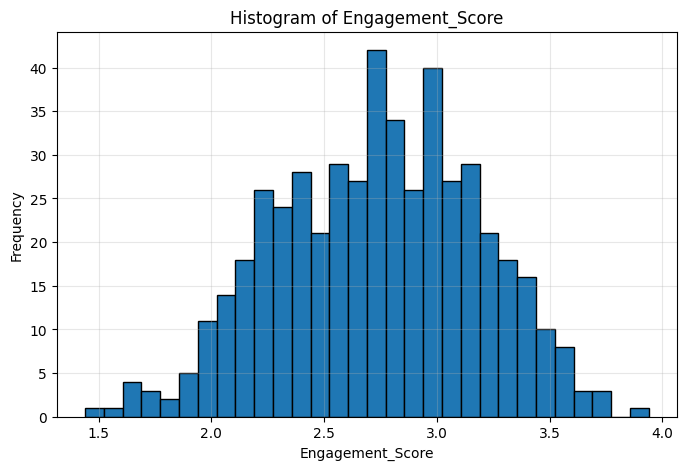

In [124]:
plot_histogram(train, missing_cols_train[0], bins=30)

Si nota una distribuzione abbastanza simmetrica e il campione è privo di outliers: si sceglie dunque di stimare i missing values tramite media campionaria.

L'unico attributo con missing values (sia nel train dataset che nel test dataset) è l"Engagement Score" che sappiamo essere di tipo continuo.
Si osserva il train dataset per comprendere quale approccio seguire con i missing values: la proporzione dei dati mancanti è sufficientemente considerevole dal non potere seguire la strategia dell'eliminazione delle osservazioni (righe del dataset) per una perdita di informazioni troppo alta. Allo stesso tempo non è così alta dall'eliminare completamente la variabile "Engagement Score" dalle variabili predittive. Quindi optiamo per una stima dei missing values e la sostituzione dei dati mancanti con tali stime. Tale approccio viene svolto anche sul test usando come stima quella presa dal train dataset.

In [125]:
train, mean = handle_missing_values_with_mean(train, col=missing_cols_train[0])
train[missing_cols_train[0]] = train[missing_cols_train[0]].fillna(mean)
train_with_label[missing_cols_train[0]] = train_with_label[missing_cols_train[0]].fillna(mean)
test[missing_cols_train[0]] = test[missing_cols_train[0]].fillna(mean)

# Check
summary_train = missing_summary(train)
if summary_train is None:
    print('Nessun valore mancante nel train set.')
else:
    print('Colonne con valori mancanti (train):')
    print(summary_train)

summary_test = missing_summary(test)
if summary_test is None:
    print('Nessun valore mancante nel test set.')
else:
    print('Colonne con valori mancanti (test):')
    print(summary_test)

Nessun valore mancante nel train set.
Nessun valore mancante nel test set.


### 4.3 Analisi e gestione dei dati duplicati
Non ci sono data object duplicati

In [126]:
dup_train = find_duplicate_rows(train_with_label)

Nessuna riga duplicata trovata.


### 4.4 Analisi e gestione outliers
DA FARE
Nelle slide di esercitazione si parla di analisi univariata, bivariata e multivariata
Restituire train e train_with_label senza outliers

### 4.5 Analisi e gestione dei wrong data
I wrong data sono quelle osservazioni che non rispettano il dominio rispettivo.
Considerando gli attributes values di ciascun attributo questi possiedono un range sensato (solitamente positivo): per esempio età va dai 18 ai 60 anni, la distanza va da 1.00 a 29.00, ecc. Questo è visibile nella prima tabella stampata. L'unico attributo con attribute values negativi è "Tenure_instability" che è l'indicatore del rapporto tra stagnazione nella carriera e anzianità aziendale (un valore basso indicherebbe una crescita regolare e coerente con gli anni). 


Corr YearsAtCompany vs Tenure_Instability: -0.4445
Corr YearsSinceLastPromotion vs Tenure_Instability: 0.5178
Corr PromotionRatio vs Tenure_Instability: 0.9699


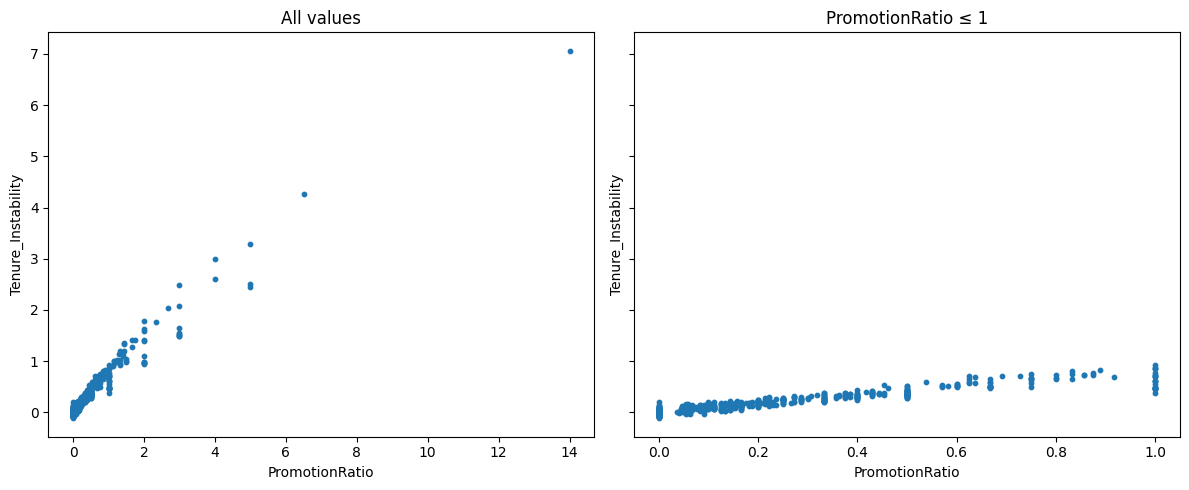

In [127]:
# Correlazioni base
corr_yac = train["YearsAtCompany"].corr(train["Tenure_Instability"])
corr_yslp = train["YearsSinceLastPromotion"].corr(train["Tenure_Instability"])

print(f"Corr YearsAtCompany vs Tenure_Instability: {corr_yac:.4f}")
print(f"Corr YearsSinceLastPromotion vs Tenure_Instability: {corr_yslp:.4f}")

# Feature temporanea (NON modifica train)
years_at_company = train["YearsAtCompany"].replace(0, np.nan)
promotion_ratio = train["YearsSinceLastPromotion"] / years_at_company

# gestione inf/nan solo sulla variabile temporanea
promotion_ratio = promotion_ratio.replace([np.inf, -np.inf], np.nan)

corr_ratio = promotion_ratio.corr(train["Tenure_Instability"])
print(f"Corr PromotionRatio vs Tenure_Instability: {corr_ratio:.4f}")

# mask senza modificare nulla
mask = promotion_ratio <= 1

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].scatter(promotion_ratio, train["Tenure_Instability"], s=10)
axes[0].set_title("All values")

axes[1].scatter(promotion_ratio[mask], train["Tenure_Instability"][mask], s=10)
axes[1].set_title("PromotionRatio ≤ 1")

for ax in axes:
    ax.set_xlabel("PromotionRatio")
    ax.set_ylabel("Tenure_Instability")

plt.tight_layout()
plt.show()

Si nota dai valori di correlazione e dai plot che valori negativi di Tenure_Instability sono tipicamente associati a pochi anni dall’ultima promozione e/o a un’elevata anzianità aziendale. Questo è coerente con l’idea che una promozione recente indichi crescita e che un’anzianità maggiore riduca l’instabilità (se al denominatore).
Pertanto, i valori negativi non saranno considerati errori, ma situazioni di maggiore stabilità e rientrano nel dominio della variabile.

# 5. Data preparation: Feature Selection, Feature Creation, Discretization, Encoding and Normalization

### 5.1 Feature Selection e Feature Creation
1) Si analizzano gli attributi e in particolare si identificano gli attributi rindondanti o poco informativi (in termini di task di classificazione di attrition)
Gli attributi rindondanti vengono identificati tramite due strumenti:
-> analisi correlazione: due attributi con alta correlazione in valore assoluto sono considerabili rindondanti
-> PCA: permetta di studiare le direzioni di massima varianza ovvero che massimizzano l'informazione all'interno dello spazio degli attributi 
Gli attributi poco informativi vengono identificati andando ad osservare come e se la label cambia al variare dello stesso.
2) Scelta e rimozione/creazione di attributi

#### Correlazione tra feature numeriche

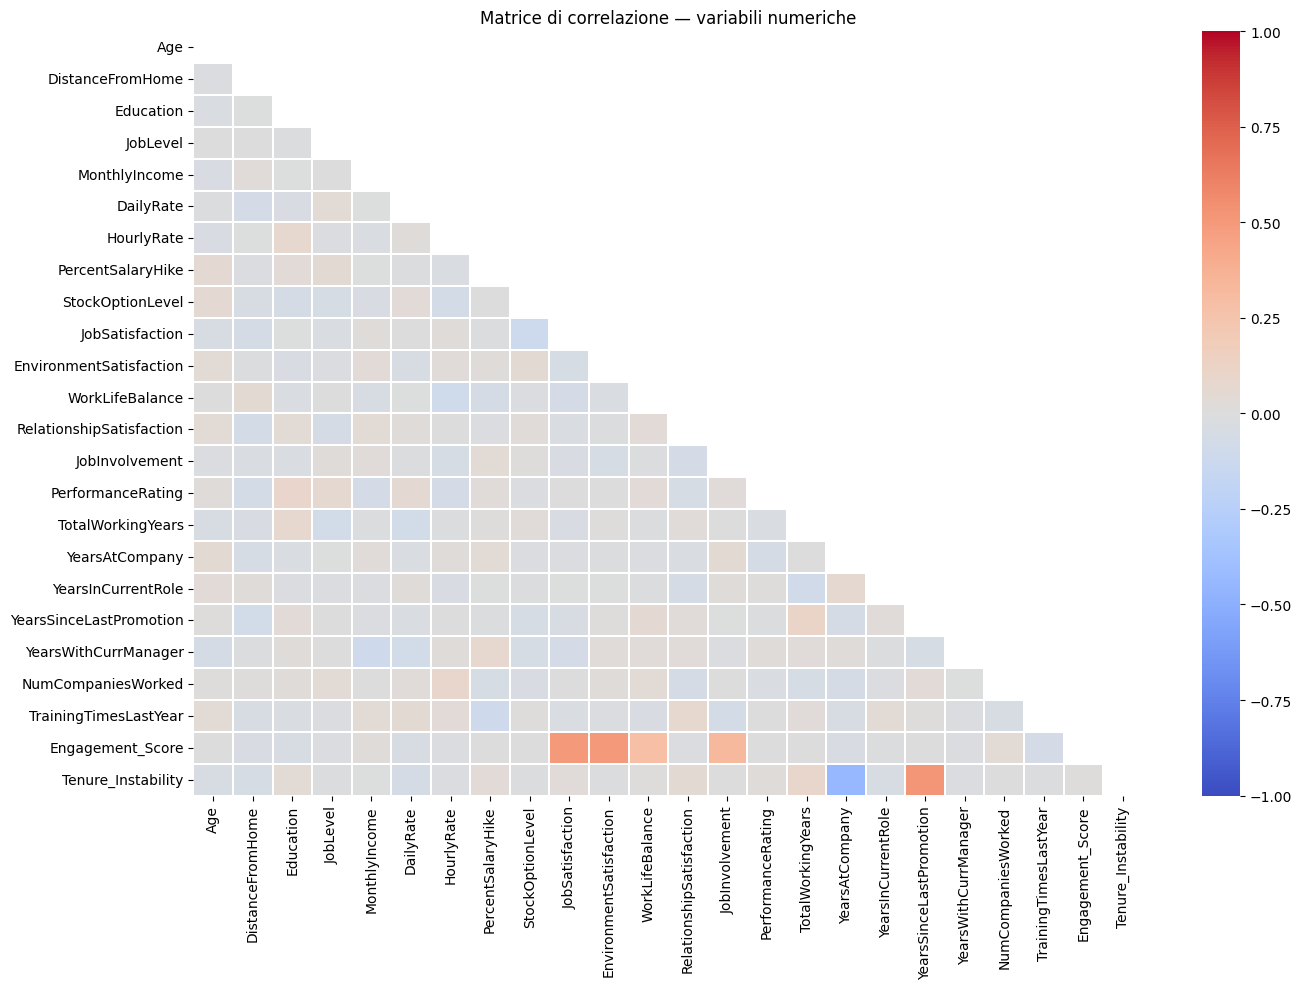

In [128]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = train[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, vmin=-1, vmax=1)
plt.title('Matrice di correlazione — variabili numeriche')
plt.tight_layout()
plt.show()

Le variabili numeriche del dataset mostrano correlazioni generalmente basse, con due sole eccezioni rilevanti: 
- Engagement score sembra correlare molto con Job Satisfaction e Environment Satisfaction
- Si nota con evidenza l'alta correlazione positiva tra YearsSinceLastPromotion e TenureInstability e l'alta correlazione negativa tra YearsAtCompany e TenureInstability. Questo era già stato notato e studiato in precedenza durante l'analisi dei wrong data. In particolare si era notato che la correlazione tra la feature generata - dal rapporto tra YearsSinceLastPromotion e YearsAtCompany - e TenureInstability è pari a 0.9699.
A partire dalla heatmap rappresentante la matrice di correlazione andiamo a definire dei gruppi di attributi dove analizzare nel dettaglio la correlazione. 

In [129]:

# TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager potrebbero essere correlate positivamente tra loro
group_anzianita = ['TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
# Il livello e lo stipendio potrebbero essere positivamente correlate
group_livello = ['JobLevel', 'MonthlyIncome']
# Età e il numero di anni potrebbero essere positivamente correlate
group_eta = ['Age', 'TotalWorkingYears']
# Gli attributi della sfera dell'engagement potrebbero essere positivamente correlati
group_engagement = ['Engagement_Score', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction', 'JobInvolvement']
gruppi = {'Anzianità aziendale' : group_anzianita,'JobLevel vs MonthlyIncome': group_livello,'Age vs TotalWorkingYears' : group_eta, 'Engagement_Score'  : group_engagement}

for nome, cols in gruppi.items():
    print("-" * 60)
    print(f"Gruppo: {nome}")
    print("-" * 60)
    print(train[cols].corr().round(2).to_string())
    print()


------------------------------------------------------------
Gruppo: Anzianità aziendale
------------------------------------------------------------
                         TotalWorkingYears  YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager
TotalWorkingYears                     1.00            0.01               -0.09                     0.11                  0.03
YearsAtCompany                        0.01            1.00                0.06                    -0.05                  0.02
YearsInCurrentRole                   -0.09            0.06                1.00                     0.02                 -0.02
YearsSinceLastPromotion               0.11           -0.05                0.02                     1.00                 -0.05
YearsWithCurrManager                  0.03            0.02               -0.02                    -0.05                  1.00

------------------------------------------------------------
Gruppo: JobLevel vs MonthlyIncom

Non ci sono correlazioni evidenti se non quella che ci aspettavamo dalla heatmap: Engagement_Score correla moderatamente con JobSatisfaction (0.50) e EnvironmentSatisfaction (0.50).
Tutti gli altri gruppi analizzati risultano sostanzialmente indipendenti. 
Il gruppo delle variabili di anzianità aziendale (TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager) mostra valori numerici vicini allo zero.
Analogamente, JobLevel e MonthlyIncome risultano incorrelati (0.0), così come Age e TotalWorkingYears (-0.04), entrambi controintuitivi rispetto alle aspettative di dominio.

#### Principal Component Analysis

Nessuna colonna con valori NaN.


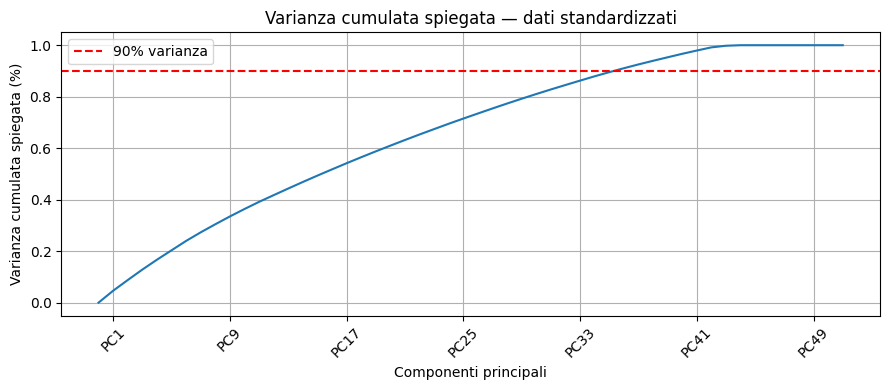

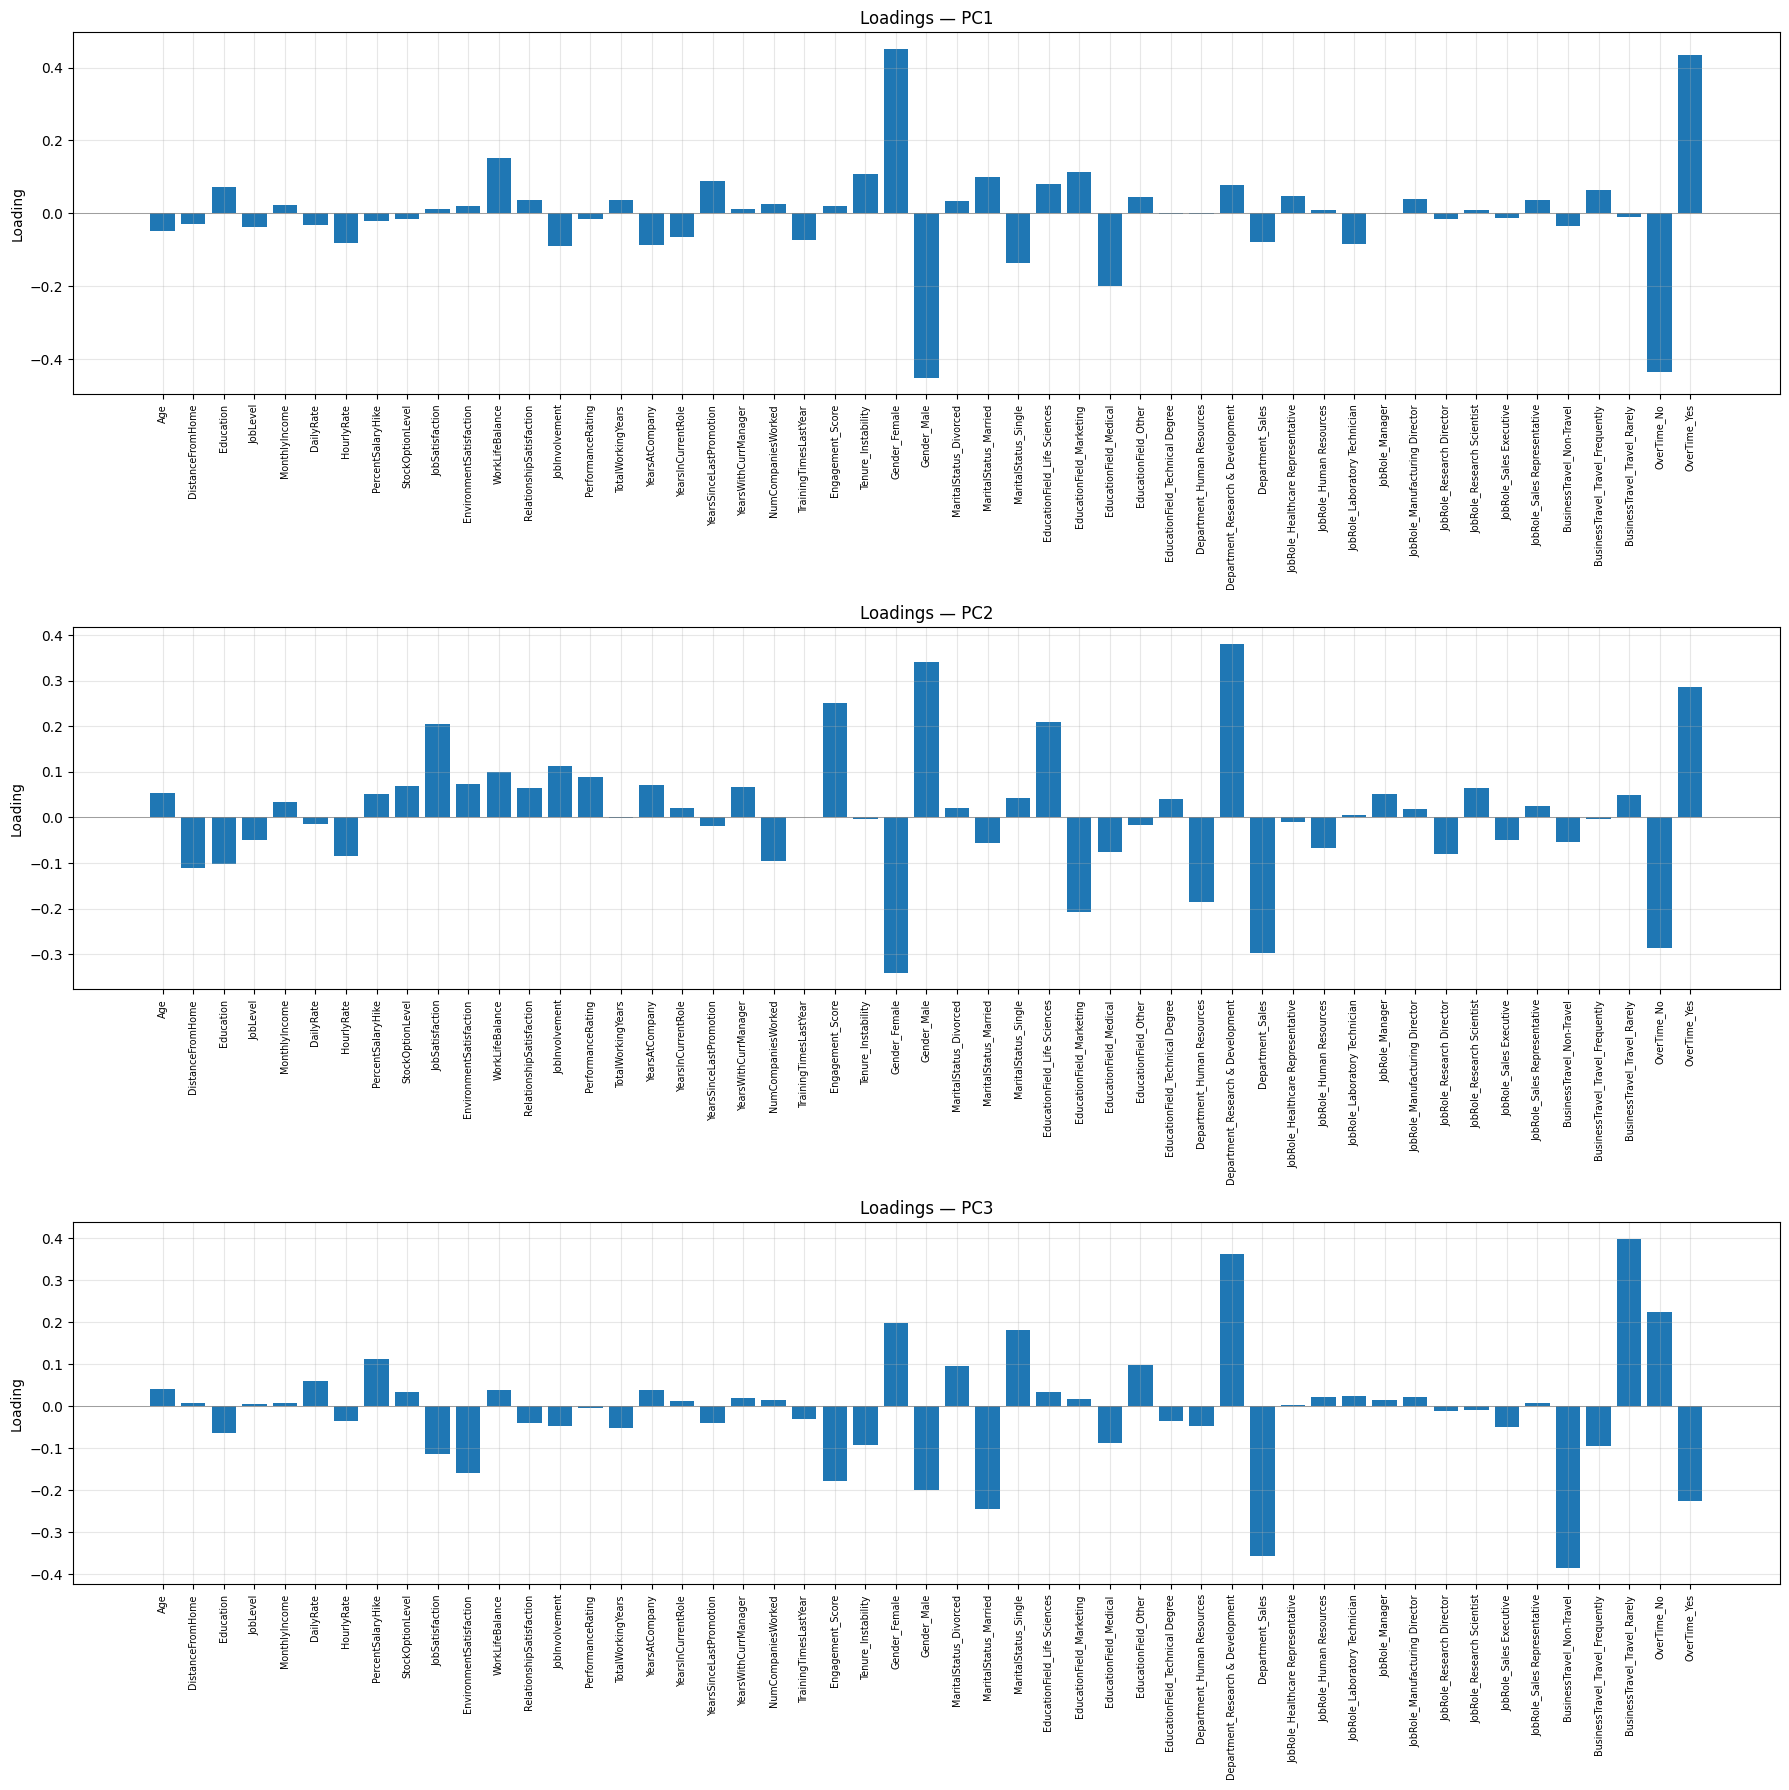

In [130]:
train_pca = train.copy()
onehot_cols = ['Gender', 'MaritalStatus', 'EducationField','Department', 'JobRole', 'BusinessTravel', 'OverTime']


def print_nan_columns(df):
    nan_counts = df.isna().sum()
    nan_counts = nan_counts[nan_counts > 0]

    if nan_counts.empty:
        print("Nessuna colonna con valori NaN.")
    else:
        print("Colonne con valori NaN:")
        print(nan_counts.sort_values(ascending=False))

print_nan_columns(train)

X_pca = pd.get_dummies(train_pca, columns=onehot_cols, dtype=int)
feature_names = X_pca.columns
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_pca)

pca = PCA()
pca.fit(X_scaled)
plt.figure(figsize=(9, 4))
plt.plot(np.insert(np.cumsum(pca.explained_variance_ratio_), 0, 0))
plt.axhline(y=0.90, color='r', linestyle='--', label='90% varianza')
plt.title('Varianza cumulata spiegata — dati standardizzati')
plt.xticks(ticks=np.arange(1, pca.n_components_ + 3, 8),labels=[f'PC{i}' for i in range(1, pca.n_components_ + 3, 8)],rotation=45)
plt.xlabel('Componenti principali')
plt.ylabel('Varianza cumulata spiegata (%)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

n_features = pca.components_.shape[1]

# ── barplot loadings per le prime 3 PC ────────────────────────────────────────
# ogni barra mostra quanto una feature originale contribuisce alla PC
fig, axes = plt.subplots(3, 1, figsize=(18, 18))
for pc_idx, ax in enumerate(axes):
    ax.bar(np.arange(n_features), pca.components_[pc_idx])
    ax.set_xticks(np.arange(n_features))
    ax.set_xticklabels(feature_names, rotation=90, fontsize='x-small')
    ax.set_title(f'Loadings — PC{pc_idx + 1}')
    ax.set_ylabel('Loading')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Dalla curva della varianza spiegata, l'informazione è distribuita su molte componenti e nessun piccolo sottoinsieme di feature domina le altre, confermando l'assenza di ridondanza forte nel dataset. I loading elevati di Gender_Male e Gender_Female in PC1 e di OverTime_No e OverTime_yes sono da attribuire principalmente all' one-hot encoding su una variabile binaria, che genera per costruzione due colonne con variabilità massima e correlazione perfetta negativa — non necessariamente un segnale di rilevanza informativa del genere. 
Le componenti PC2 e PC3 mostrano che alcune variabili tendono a variare insieme nello stesso spazio — in PC2 troviamo la conferma di quanto osservato dalla heatmap: JobSatisfaction e EngagementScore mostrano loadings entrambi positivi indicando una correlazione nella seconda direzione principale. Inoltre l'appartenenza al dipartimento R&D (+0.37) o Sales (-0.30) co-varia con JobSatisfaction (+0.20). In PC3 la frequenza di viaggio co-varia con l'appartenenza a Sales: BusinessTravel_Travel_Rarely ha loadings +0.40 e Department_Sales ha loadings -0.37. Tuttavia trattandosi di una combinazione di variabili numeriche e dummy categoriche, non è possibile interpretare questi loading come correlazioni dirette tra le feature originali — rappresentano solo direzioni di variabilità congiunta nello spazio trasformato dalla PCA.
In ogni caso queste analisi descrivono la struttura interna del dataset senza considerare la label: servono a intuire quali attributi portano informazione indipendente e quali sono ridondanti. La relazione con Attrition richiede un'analisi separata svolta di seguito. 

#### Features vs label
Si osservano le distribuzione delle variabili numeriche, separate per classe di Attrition per intuire visivamente se ci possono essere attributi che discriminano maggiormente di altri

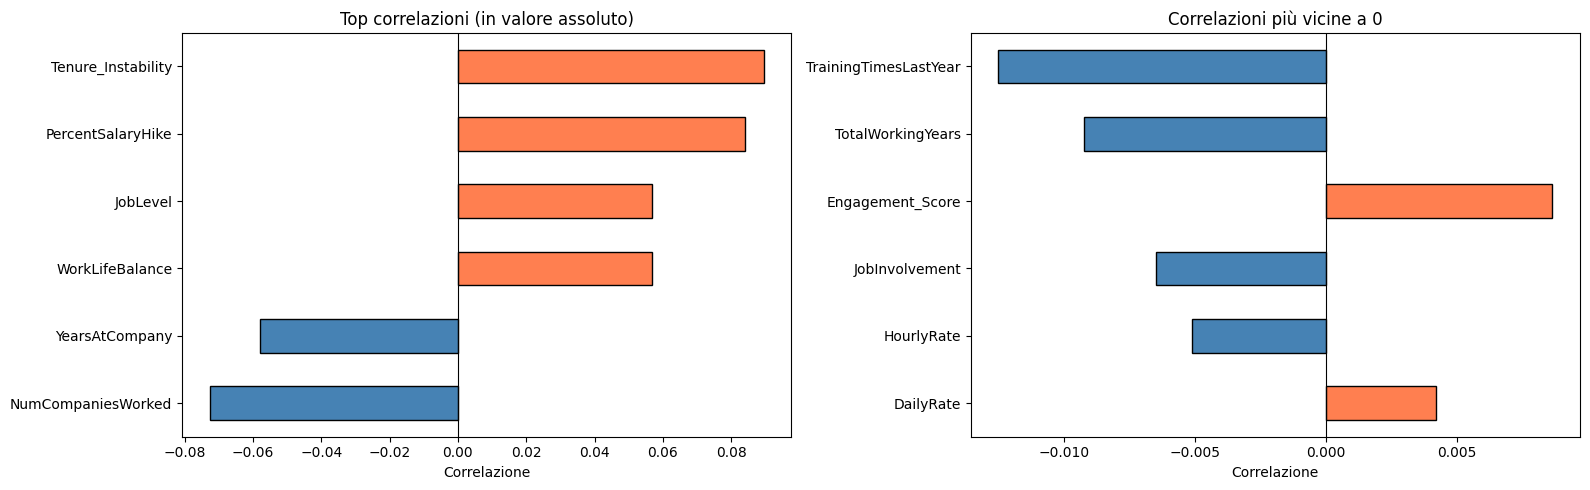

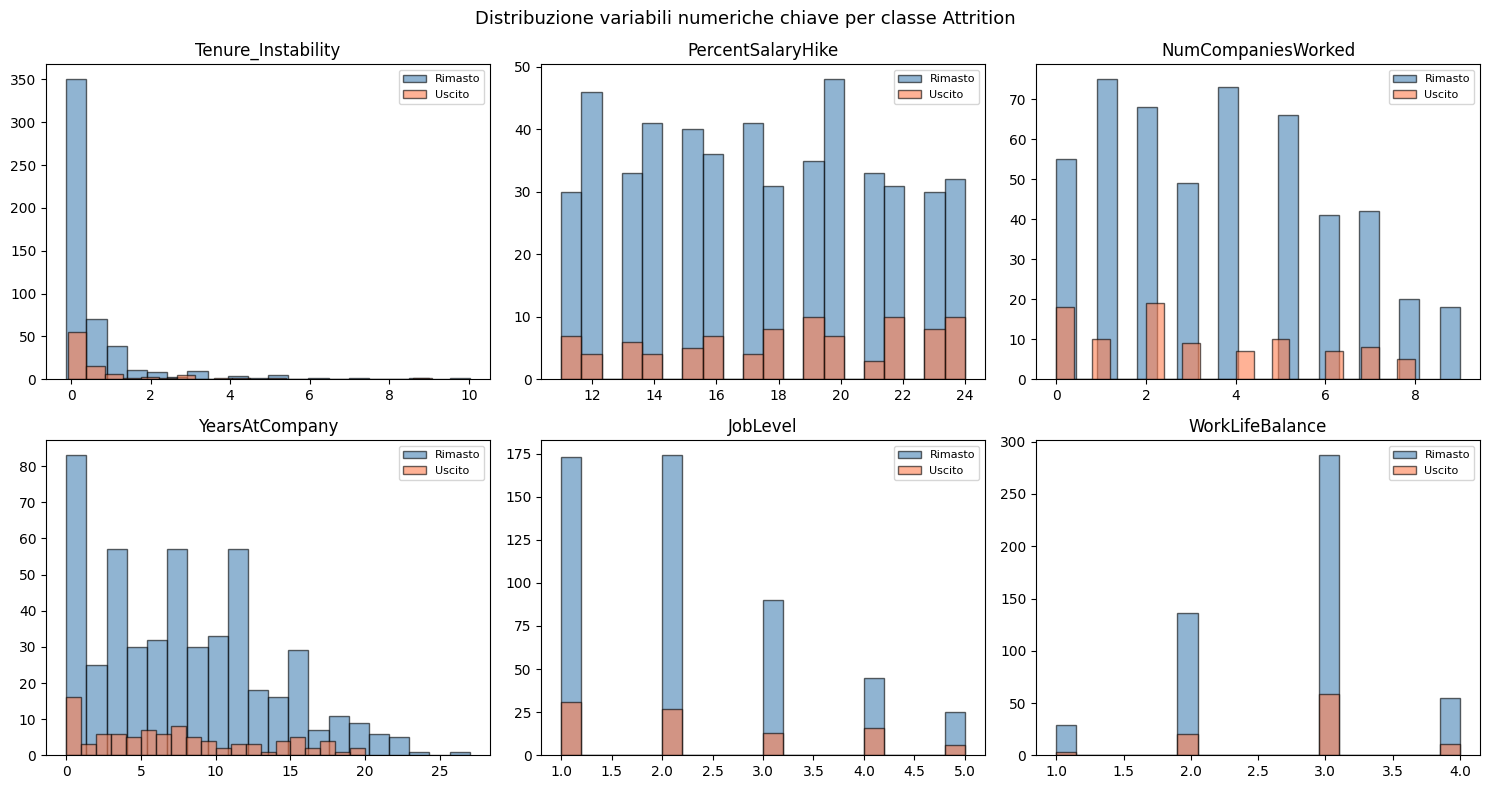

In [131]:
corr_target = train_with_label.select_dtypes(include=['int64', 'float64']).corr()['Attrition']
corr_target = corr_target.drop('Attrition')
corr_sorted = corr_target.reindex( corr_target.abs().sort_values(ascending=False).index)
corr_sorted_low = corr_target.reindex(corr_target.abs().sort_values(ascending=True).index)
top_high = corr_sorted.head(6).sort_values()
top_low = corr_sorted_low.head(6)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_high.plot( kind='barh', ax=axes[0], color=top_high.map(lambda x: 'coral' if x > 0 else 'steelblue'), edgecolor='black')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top correlazioni (in valore assoluto)')
axes[0].set_xlabel('Correlazione')
top_low.plot(kind='barh',ax=axes[1],color=top_low.map(lambda x: 'coral' if x > 0 else 'steelblue'),   edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlazioni più vicine a 0')
axes[1].set_xlabel('Correlazione')
plt.tight_layout()
plt.show()


key_num = corr_sorted.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_num):
    for val, label, color in [(0, 'Rimasto', 'steelblue'), (1, 'Uscito', 'coral')]:
        subset = train[train_with_label['Attrition'] == val][feat].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='black')
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuzione variabili numeriche chiave per classe Attrition', fontsize=13)
plt.tight_layout()
plt.show()



Tra le variabili numeriche i coefficienti di correlazione con attrition sono tutti compresi tra -0.08 e +0.09. Sono correlazioni lineari deboli. Con correlazioni più forti date da TenureInstability e NumCompaniesWorked. 
Quindi non ci sono variabili numeriche significamente predittive secondo la metrica della correlazione lineare. Ciò può essere osservato anche dalle distribuzioni (istogrammi) di attrition che non sembrano essere tanto differenti.

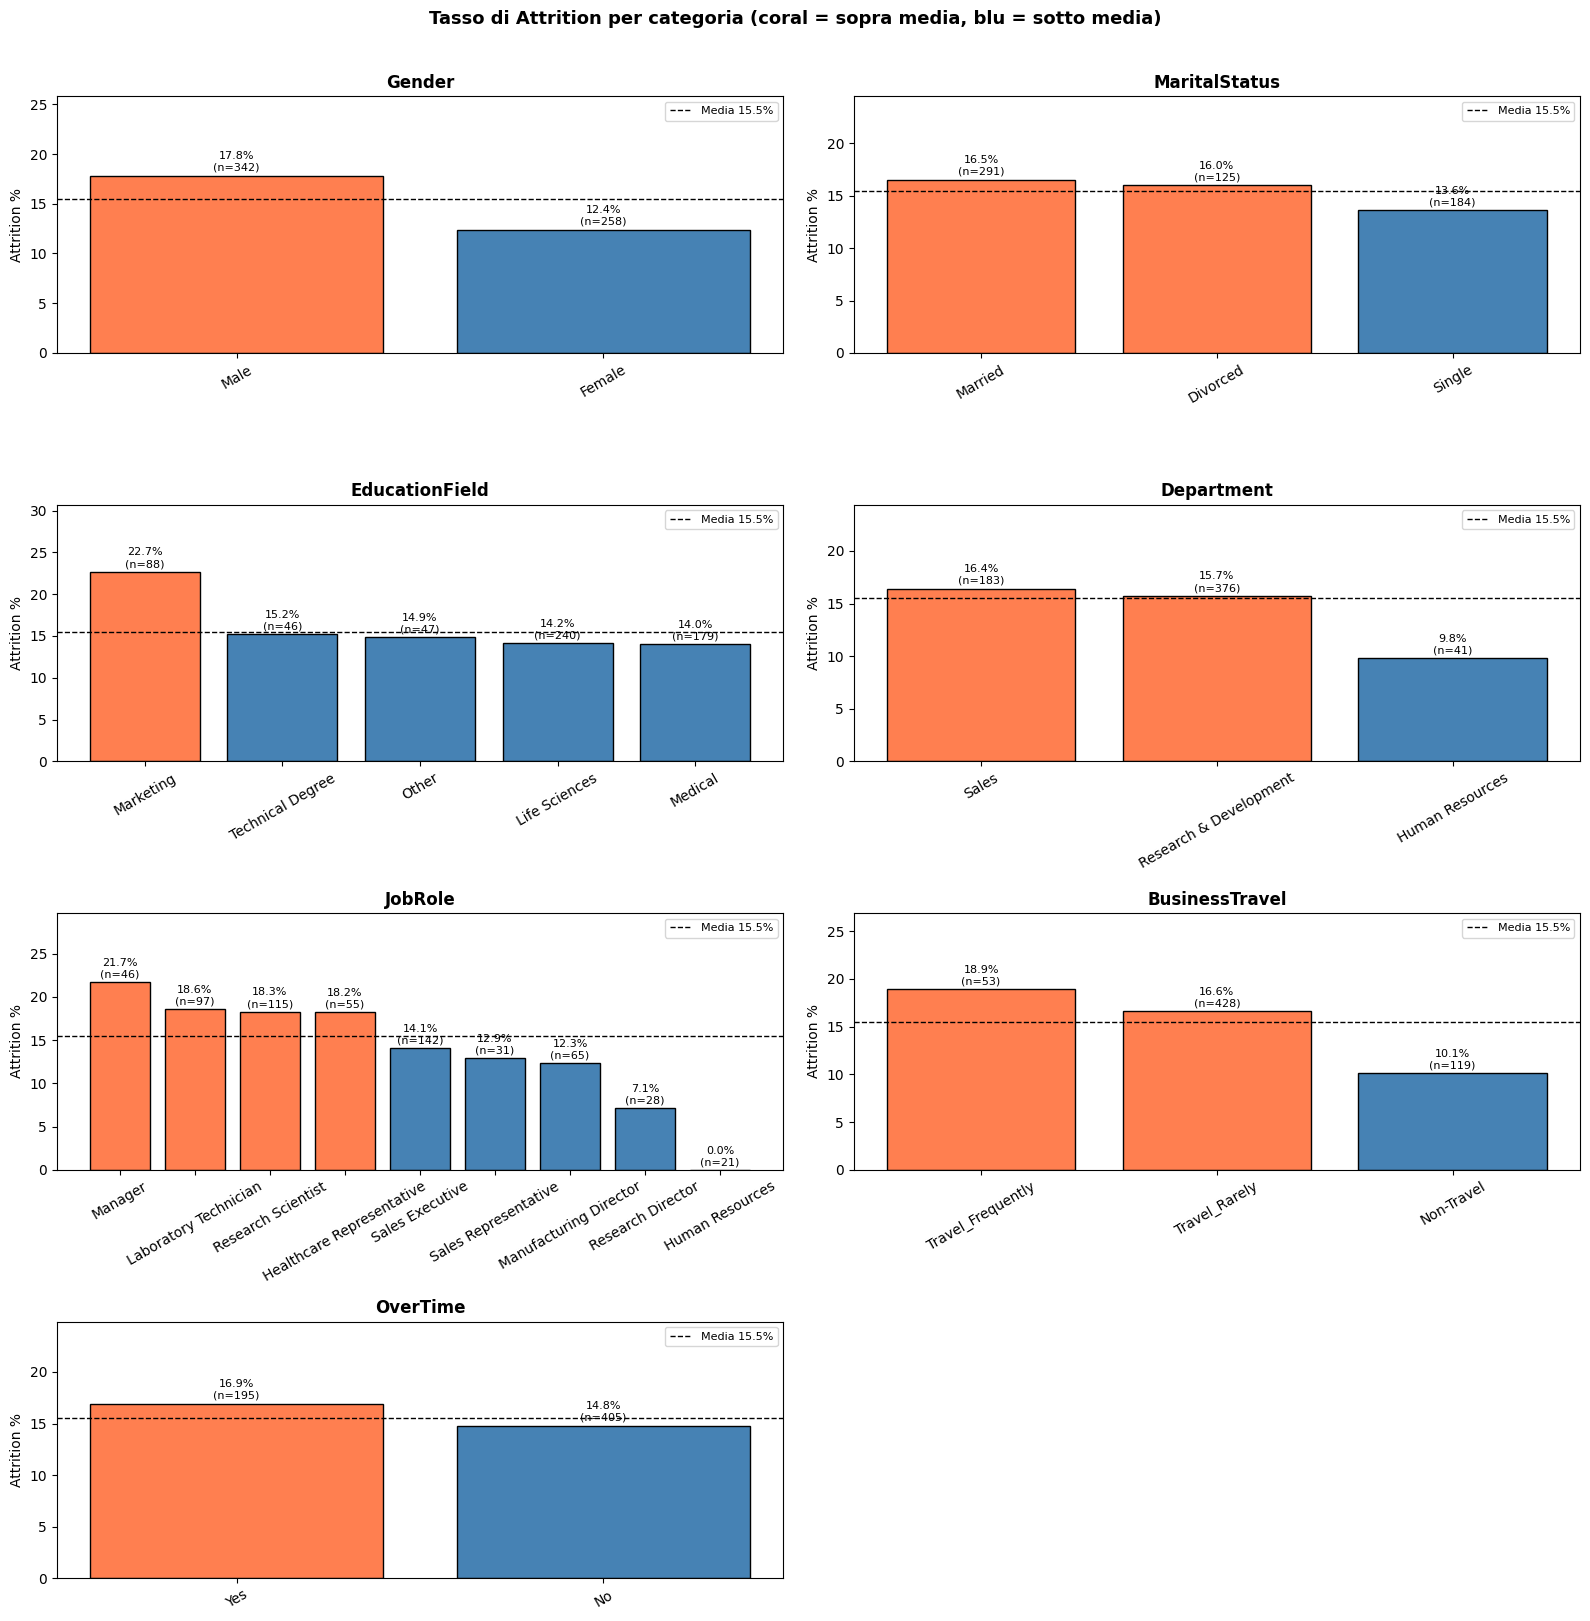

In [132]:
obj_cols = train_with_label.select_dtypes(include='object').columns.tolist()
n_cols = 2
n_rows = math.ceil(len(obj_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
mean_attrition = train_with_label['Attrition'].mean() * 100
for i, col in enumerate(obj_cols):
    rates = (train_with_label.groupby(col)['Attrition'].agg(['sum', 'count']).rename(columns={'sum': 'Usciti', 'count': 'Totale'}))
    rates['Attrition%'] = (rates['Usciti'] / rates['Totale'] * 100).round(1)
    rates = rates.sort_values('Attrition%', ascending=False)
    colors = ['coral' if v > mean_attrition else 'steelblue' for v in rates['Attrition%']]
    bars = axes[i].bar(rates.index, rates['Attrition%'], color=colors, edgecolor='black')
    # linea media dataset
    axes[i].axhline(mean_attrition, color='black', linestyle='--', linewidth=1, label=f'Media {mean_attrition:.1f}%')
    # etichette sulle barre
    for bar, (_, row) in zip(bars, rates.iterrows()):
        axes[i].text(bar.get_x() + bar.get_width()/2,bar.get_height() + 0.3,f"{row['Attrition%']}%\n(n={int(row['Totale'])})",ha='center', va='bottom', fontsize=8)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Attrition %')
    axes[i].set_ylim(0, rates['Attrition%'].max() + 8)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Tasso di Attrition per categoria (coral = sopra media, blu = sotto media)',fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Anche tra le categoriche non si notano variabili altamente discriminanti. Notiamo leggere indicazioni:
- Chi viaggia di più lascia di più (vedi BusinessTravel)
- Chi lavora nel Marketing tenderà a lasciare maggiormente rispetto agli altri camoi
- Tendenzialmente l'attrition dipende dal ruolo: manager ha mediamente alta attrition.
Notiamo che attributi come OverTime non contribuirebbero significativamente all'attrition.

### 5.2 Discretization
1) Selezione attributi da discretizzare: scegliamo quegli attributi continui oppure con vasto numero di attribute values unici e quegli attributi che si prestano
a essere discretizzati. 
2) Individuazione tecnica e numero di bin per la discretizzazione: nel caso di distribuzioni altamente asimmetrice la scelta ricade sulla discretizzazione per frequenza, il numero di bins considerato è pari a 5, riferimento standard. Nel caso di attributi con range elevati si sono scelti valori più alti per evitare


FARE

iniziato con marti:
- la dimensione del dominio attributi in tabella iniziale
Gli attributi discretizzati per frequenza sono:
In 5 bins:
- età -> distribuzione simil gaussiana
In 7 bins:
- MonthlyIncome  -> distribuzione skewed positiva

Gli attributi discretizzati per size:
- TenureInstability -> not sacch

MonthlyIncome -> dato continuo
Age 
TotalWorkingYears
YearsAtCompany


Alla fine abbiamo sia il dataset non discretizzato che quello discretizzato (l'uso della discretizzazione dipende dagli algoritmi)

### 5.3 Encoding variabili categoriche
Si mappano attributi categoriali in un dominio numerico. Le principali tecniche sono label encoding - maggiormente adatto nel caso di variabili ordinali - e one hot encoding - preferibile nel caso di variabili non ordinali. Nel nostro caso le variabili 'Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel' e 'OverTime' non possiedono nozione di ordine quindi si esegue una codifica one-hot.

In [133]:
onehot_cols = ['Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel', 'OverTime']
train = pd.get_dummies(train, columns= onehot_cols)
test = pd.get_dummies(test, columns= onehot_cols)

### 5.4 Normalization
Si utilizza come metodo di normalizzazione il min max scaler, questo perchè esso rimane un metodo robusto in assenza di outliers (rimossi durante il preprocessing) ed è preferibile nel caso ci siano molteplici variabili ordinali che quindi difficilmente possiedono distribuzione simil gaussiana.

In [134]:
scaler = MinMaxScaler()
cols_to_scale = [c for c in train.columns]
scaler.fit(train[cols_to_scale])

train[cols_to_scale] = scaler.transform(train[cols_to_scale])
test[cols_to_scale] = scaler.transform(test[cols_to_scale])


## 2. Creazione validation set
Viene creato il validation dataset utile per:
- Tuning dei parametri dei modelli
- Eventuale early stopping

FARE, dataset piccolo -> cross valdation?

DA QUI IN GIU' ANCORA DA VEDERE

### Funzione di valutazione

Dato lo sbilanciamento (≈15% classe 1), si calcolano: Accuracy, Precision, Recall, F1-score e ROC-AUC. Il **Recall** è la metrica più critica in questo contesto: un falso negativo (dipendente a rischio non identificato) ha un costo di business elevato.

In [135]:
def evaluate(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan

    print(f'=== {name} ===')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {auc:.4f}')

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm,
                         index=['Reale: Rimasto', 'Reale: Uscito'],
                         columns=['Pred: Rimasto', 'Pred: Uscito'])
    print('\nConfusion Matrix:')
    print(cm_df)
    print()

    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'AUC': auc}

## 5. Algoritmo 1: Decision Tree

Il Decision Tree costruisce una struttura ad albero partizionando ricorsivamente i dati secondo una misura di impurità. Con il criterio **Entropy** (Information Gain):

$$H(S) = -\sum_{i} p_i \log_2(p_i)$$

Con il criterio **Gini**:

$$G(S) = 1 - \sum_{i} p_i^2$$

Il parametro `class_weight='balanced'` compensa lo sbilanciamento tra le classi assegnando pesi inversamente proporzionali alla frequenza.

In [136]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_impurity_decrease=0.001,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

res_dt = evaluate('Decision Tree (depth=10, entropy)', y_test, y_pred_dt, y_prob_dt)

NameError: name 'X_train' is not defined

### 5.1 Analisi di Sensitività — Decision Tree

Variamo `max_depth` e `criterion` per osservare l'effetto sulle metriche sul test set. USARE VALIDATION DATASET

In [ ]:
depths   = [2, 3, 5, 8, 10, 15, 20, None]
criteria = ['entropy', 'gini']

rows_dt = []
for crit in criteria:
    for d in depths:
        clf = DecisionTreeClassifier(criterion=crit, max_depth=d,
                                     class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)
        rows_dt.append({
            'criterion': crit,
            'max_depth': str(d) if d is not None else 'None',
            'Accuracy': accuracy_score(y_test, pred),
            'Recall':   recall_score(y_test, pred, zero_division=0),
            'F1':       f1_score(y_test, pred, zero_division=0)
        })

df_sens_dt = pd.DataFrame(rows_dt)
df_sens_dt.round(4)

,criterion,max_depth,Accuracy,Recall,F1
0,entropy,2,0.2467,0.8261,0.2517
1,entropy,3,0.2467,0.8261,0.2517
2,entropy,5,0.3867,0.6087,0.2333
3,entropy,8,0.4267,0.5652,0.2321
4,entropy,10,0.4667,0.3478,0.1667
5,entropy,15,0.6800,0.0870,0.0769
6,entropy,20,0.7333,0.1304,0.1304
7,entropy,None,0.7333,0.1304,0.1304
8,gini,2,0.7000,0.2609,0.2105
9,gini,3,0.6733,0.3478,0.2462


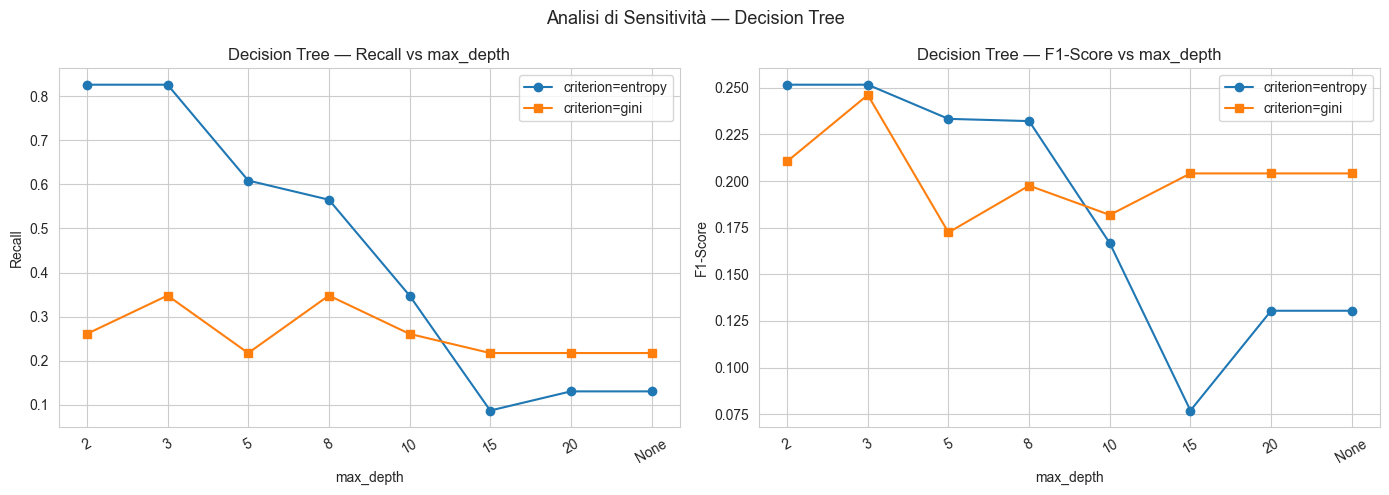

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for crit, ls in [('entropy', '-o'), ('gini', '-s')]:
    sub = df_sens_dt[df_sens_dt['criterion'] == crit]
    axes[0].plot(sub['max_depth'], sub['Recall'],   ls, label=f'criterion={crit}')
    axes[1].plot(sub['max_depth'], sub['F1'],       ls, label=f'criterion={crit}')

for ax, metric in zip(axes, ['Recall', 'F1-Score']):
    ax.set_title(f'Decision Tree — {metric} vs max_depth')
    ax.set_xlabel('max_depth')
    ax.set_ylabel(metric)
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Analisi di Sensitività — Decision Tree', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Algoritmo 2: Random Forest

Il Random Forest è un metodo ensemble che addestra $T$ alberi decisionali su campioni bootstrap del dataset, usando a ogni split un sottoinsieme casuale di feature (di dimensione $\sqrt{p}$ per classificazione). La predizione finale è il voto di maggioranza:

$$\hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x})\}$$

Rispetto al singolo albero, riduce la varianza mantenendo bias basso.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

res_rf = evaluate('Random Forest (100 trees, depth=10)', y_test, y_pred_rf, y_prob_rf)

=== Random Forest (100 trees, depth=10) ===
  Accuracy:  0.8467
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  ROC-AUC:   0.4502

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto            127             0
Reale: Uscito              23             0



### 6.1 Analisi di Sensitività — Random Forest con GridSearchCV

Usiamo la Cross-Validation (k=5) ottimizzando F1-score per trovare la migliore combinazione di `n_estimators` e `max_depth`.  USARE VALIDATION DATASET

In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [5, 10, 20, None]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print(f'Migliori parametri: {gs_rf.best_params_}')
print(f'Miglior F1 (CV):    {gs_rf.best_score_:.4f}')

Migliori parametri: {'max_depth': 5, 'n_estimators': 50}
Miglior F1 (CV):    0.0508


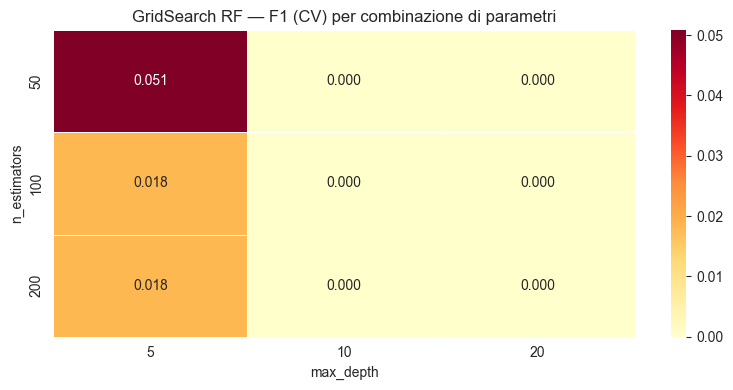

In [ ]:
cv_res = pd.DataFrame(gs_rf.cv_results_)
pivot  = cv_res.pivot_table(values='mean_test_score',
                             index='param_n_estimators',
                             columns='param_max_depth')

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('GridSearch RF — F1 (CV) per combinazione di parametri')
plt.xlabel('max_depth')
plt.ylabel('n_estimators')
plt.tight_layout()
plt.show()

In [ ]:
best_rf = gs_rf.best_estimator_

y_pred_rf_best = best_rf.predict(X_test)
y_prob_rf_best = best_rf.predict_proba(X_test)[:, 1]

res_rf_best = evaluate('Random Forest (Best params)', y_test, y_pred_rf_best, y_prob_rf_best)

=== Random Forest (Best params) ===
  Accuracy:  0.7933
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  ROC-AUC:   0.4036

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto            119             8
Reale: Uscito              23             0



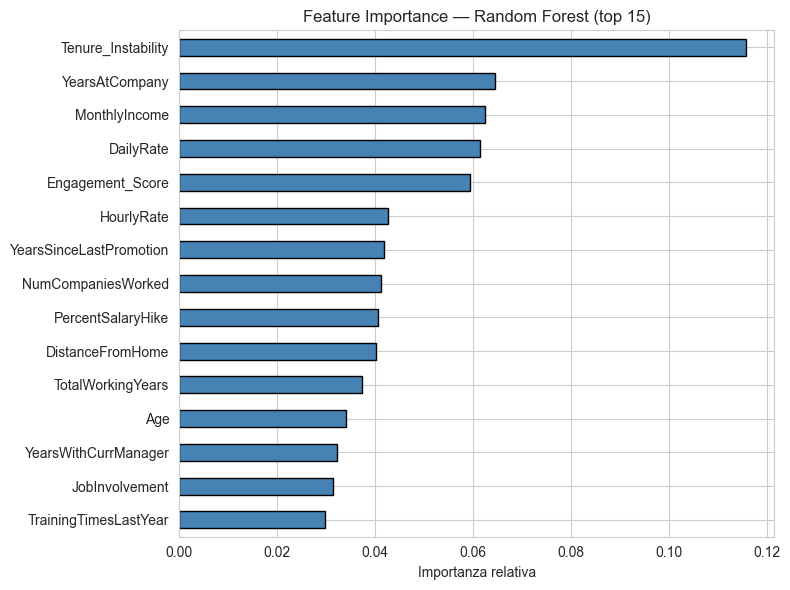


Top 5 variabili più importanti:
Tenure_Instability    0.1157
YearsAtCompany        0.0645
MonthlyIncome         0.0624
DailyRate             0.0614
Engagement_Score      0.0595
dtype: float64


In [ ]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest (top 15)')
plt.xlabel('Importanza relativa')
plt.tight_layout()
plt.show()

print('\nTop 5 variabili più importanti:')
print(feat_imp.sort_values(ascending=False).head(5).round(4))

## 7. Algoritmo 3: Logistic Regression

La regressione logistica modella direttamente la probabilità della classe positiva tramite la funzione sigmoide:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x} + b)}}$$

Il parametro $C = 1/\lambda$ controlla la regolarizzazione L2: valori piccoli aumentano la penalizzazione, riducendo il rischio di overfitting. Richiede feature scalate.

In [ ]:
lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

res_lr = evaluate('Logistic Regression (C=1.0)', y_test, y_pred_lr, y_prob_lr)

=== Logistic Regression (C=1.0) ===
  Accuracy:  0.5400
  Precision: 0.1167
  Recall:    0.3043
  F1-Score:  0.1687
  ROC-AUC:   0.4043

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             74            53
Reale: Uscito              16             7



### 7.1 Analisi di Sensitività — Logistic Regression

Variazione del parametro di regolarizzazione $C$.

In [ ]:
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]
rows_lr  = []

for c in C_values:
    model = LogisticRegression(C=c, class_weight='balanced',
                                max_iter=1000, random_state=42)
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    rows_lr.append({
        'C': c,
        'Accuracy': accuracy_score(y_test, pred),
        'Recall':   recall_score(y_test, pred, zero_division=0),
        'F1':       f1_score(y_test, pred, zero_division=0)
    })

df_sens_lr = pd.DataFrame(rows_lr)
print(df_sens_lr.round(4))

         C  Accuracy  Recall      F1
0    0.001    0.5933  0.3913  0.2278
1    0.010    0.5600  0.3478  0.1951
2    0.100    0.5467  0.3043  0.1707
3    0.500    0.5400  0.3043  0.1687
4    1.000    0.5400  0.3043  0.1687
5    5.000    0.5400  0.3043  0.1687
6   10.000    0.5400  0.3043  0.1687
7  100.000    0.5400  0.3043  0.1687


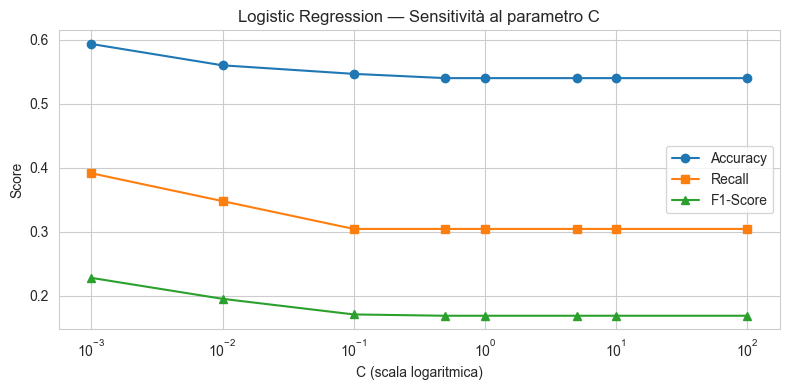

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(df_sens_lr['C'], df_sens_lr['Accuracy'], '-o', label='Accuracy')
plt.plot(df_sens_lr['C'], df_sens_lr['Recall'],   '-s', label='Recall')
plt.plot(df_sens_lr['C'], df_sens_lr['F1'],       '-^', label='F1-Score')
plt.xscale('log')
plt.title('Logistic Regression — Sensitività al parametro C')
plt.xlabel('C (scala logaritmica)')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

Selezioniamo il C ottimale e riaddestriamo il modello finale.

In [ ]:
best_C = df_sens_lr.loc[df_sens_lr['F1'].idxmax(), 'C']
print(f'C ottimale per F1: {best_C}')

lr_best = LogisticRegression(C=best_C, class_weight='balanced',
                              max_iter=1000, random_state=42)
lr_best.fit(X_train_sc, y_train)

y_pred_lr_best = lr_best.predict(X_test_sc)
y_prob_lr_best = lr_best.predict_proba(X_test_sc)[:, 1]

res_lr_best = evaluate(f'Logistic Regression (C={best_C})', y_test, y_pred_lr_best, y_prob_lr_best)

C ottimale per F1: 0.001
=== Logistic Regression (C=0.001) ===
  Accuracy:  0.5933
  Precision: 0.1607
  Recall:    0.3913
  F1-Score:  0.2278
  ROC-AUC:   0.4317

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             80            47
Reale: Uscito              14             9



## 8. Analisi Comparativa

Confronto finale dei tre modelli ottimali sul test set.

In [ ]:
summary = pd.DataFrame([res_dt, res_rf_best, res_lr_best])
summary = summary.set_index('Model')
summary.round(4)

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
"Decision Tree (depth=10, entropy)",0.4667,0.1096,0.3478,0.1667,0.4136
Random Forest (Best params),0.7933,0.0000,0.0000,0.0000,0.4036
Logistic Regression (C=0.001),0.5933,0.1607,0.3913,0.2278,0.4317


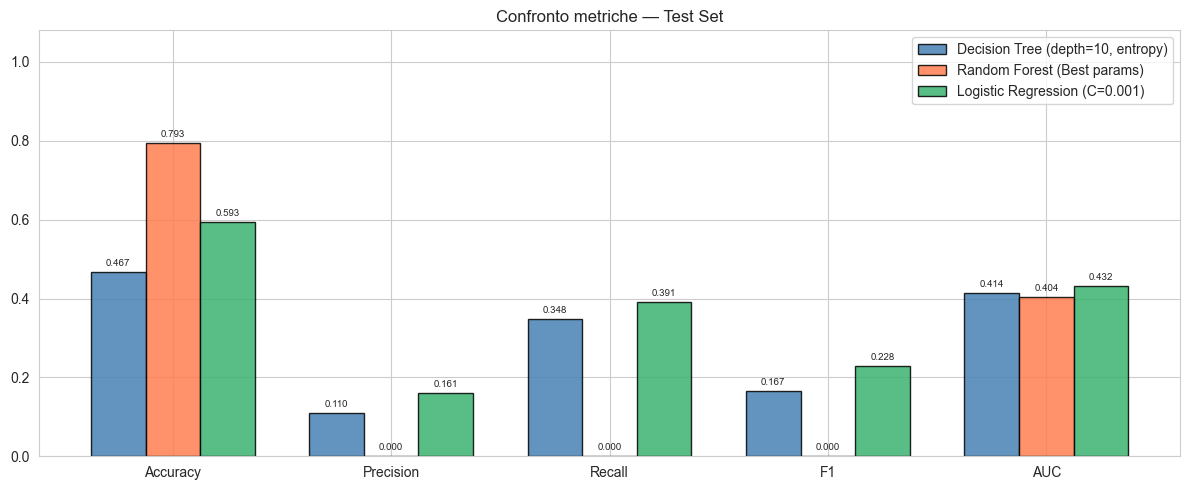

In [ ]:
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x      = np.arange(len(metrics_plot))
width  = 0.25
colors = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, color) in enumerate(zip(summary.index, colors)):
    vals = [summary.loc[model, m] for m in metrics_plot]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=color, edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot)
ax.set_ylim(0, 1.08)
ax.set_title('Confronto metriche — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

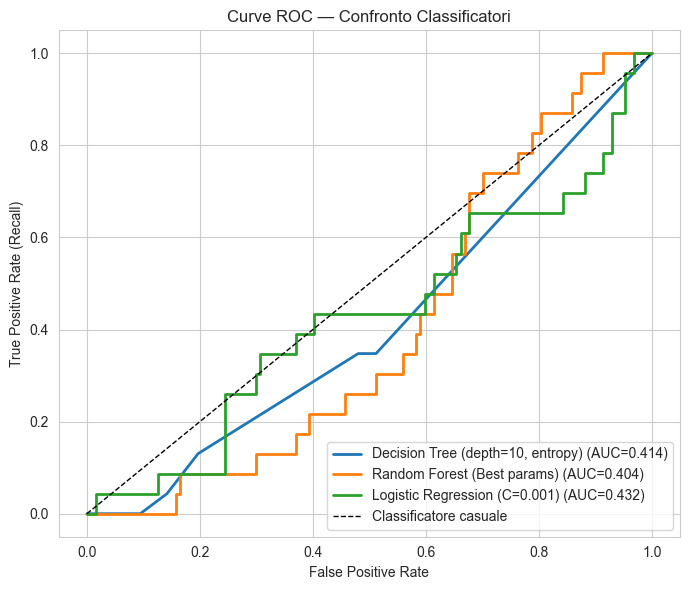

In [ ]:
plt.figure(figsize=(7, 6))

for name, y_prob in [
    (res_dt['Model'],      y_prob_dt),
    (res_rf_best['Model'], y_prob_rf_best),
    (res_lr_best['Model'], y_prob_lr_best)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classificatore casuale')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curve ROC — Confronto Classificatori')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

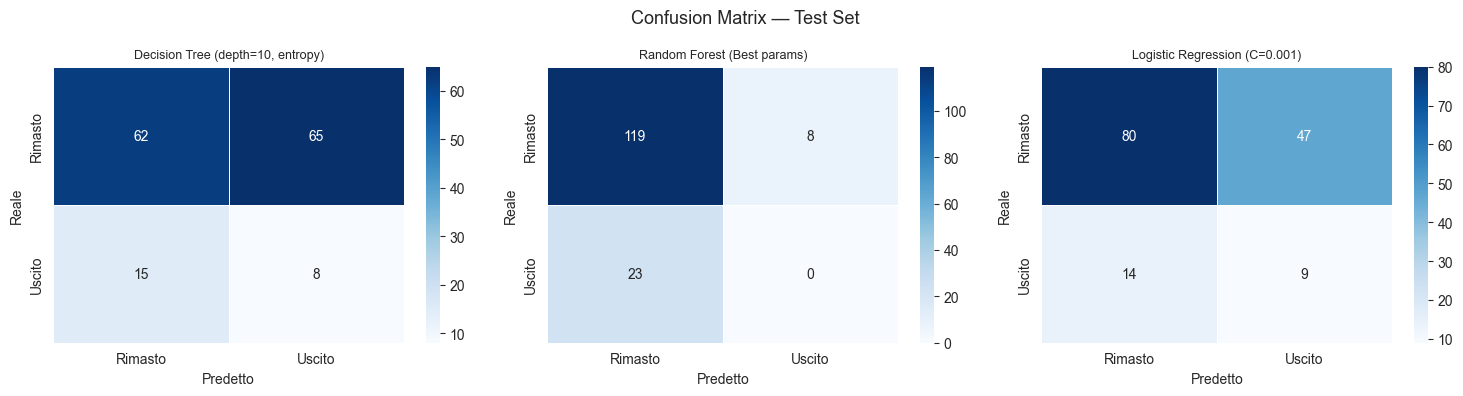

In [ ]:
models_cm = [
    (res_dt['Model'],      y_pred_dt),
    (res_rf_best['Model'], y_pred_rf_best),
    (res_lr_best['Model'], y_pred_lr_best)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, models_cm):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rimasto', 'Uscito'],
                yticklabels=['Rimasto', 'Uscito'],
                linewidths=0.5)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predetto')
    ax.set_ylabel('Reale')

plt.suptitle('Confusion Matrix — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

### 8.1 Cross-Validation sul modello migliore

Verifichiamo la robustezza del Random Forest (miglior modello) con Cross-Validation a 5 fold sul training set.

In [ ]:
rf_cv = RandomForestClassifier(**gs_rf.best_params_,
                                class_weight='balanced',
                                random_state=42, n_jobs=-1)

y_cv_pred = cross_val_predict(rf_cv, X_train, y_train, cv=5)

print('=== Random Forest — Cross-Validation (5-fold) sul train ===')
print(f'  Accuracy:  {accuracy_score(y_train, y_cv_pred):.4f}')
print(f'  Recall:    {recall_score(y_train, y_cv_pred, zero_division=0):.4f}')
print(f'  F1-Score:  {f1_score(y_train, y_cv_pred, zero_division=0):.4f}')

cm_cv = confusion_matrix(y_train, y_cv_pred)
cm_cv_df = pd.DataFrame(cm_cv,
                         index=['Reale: Rimasto', 'Reale: Uscito'],
                         columns=['Pred: Rimasto', 'Pred: Uscito'])
print('\nConfusion Matrix (CV):')
print(cm_cv_df)

=== Random Forest — Cross-Validation (5-fold) sul train ===
  Accuracy:  0.8217
  Recall:    0.0323
  F1-Score:  0.0531

Confusion Matrix (CV):
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto            490            17
Reale: Uscito              90             3


## 9. Applicazione di Business

### Sintesi dei risultati

Il **Random Forest** con parametri ottimizzati è il modello migliore per questo caso d'uso, grazie al miglior bilanciamento tra Recall e Precision sulla classe minoritaria (dipendenti a rischio abbandono).

Le variabili più importanti identificate dal modello sono coerenti con la letteratura HR:
- **MonthlyIncome / YearsAtCompany / TotalWorkingYears**: dipendenti con bassa anzianità o stipendio inferiore alla media mostrano tassi di abbandono più elevati.
- **OverTime**: chi fa frequentemente straordinari ha un rischio di abbandono significativamente superiore.
- **JobSatisfaction / EnvironmentSatisfaction**: bassi livelli di soddisfazione correlano fortemente con l'attrition.
- **BusinessTravel**: le trasferte frequenti aumentano il rischio di abbandono.

### Come sfruttare il modello in un'applicazione HR

**1. Early Warning System:** il modello può essere integrato nel sistema HRIS aziendale per generare un "risk score" mensile per ogni dipendente. L'HR team riceve alert automatici per i dipendenti con probabilità di abbandono > soglia.

**2. Interventi mirati di Retention:** segmentando i dipendenti ad alto rischio per dipartimento, ruolo e livello, l'azienda può attivare interventi specifici: revisioni salariali, piani di sviluppo, riduzione straordinari, programmi di engagement.

**3. ROI della Retention:** stimando il costo medio di sostituzione di un dipendente (recruiting + formazione + produttività persa ≈ 1-2 anni di stipendio), il modello permette di calcolare il risparmio atteso dagli interventi di retention, giustificando l'investimento in People Analytics.

**4. Monitoraggio nel tempo:** il modello va riadderato periodicamente (trimestrale/semestrale) con i nuovi dati per mantenere accuratezza su popolazioni e contesti aziendali in evoluzione.

**Nota sulle limitazioni:** il dataset è sbilanciato (≈15% attrition), il che riduce la Precision. In produzione si raccomanda di calibrare la soglia di classificazione in funzione del trade-off costo falso positivo / costo falso negativo specifico dell'azienda.